## Section 0: Environment Setup

This section imports all required libraries for model training and option pricing experiments.

All experiments use a **custom NumPy-based Monte Carlo implementation** to simulate Geometric Brownian Motion (GBM) paths and compute Asian option payoffs. QuantLib is not required to run this notebook.

**Install dependencies:** `pip install -r requirements.txt`

Key dependencies:
- **NumPy / SciPy**: stochastic path generation and numerical computation
- **PyTorch**: deep neural network implementation (MLP / CNN / LSTM / CNN-LSTM / TCN)
- **Matplotlib / Seaborn**: visualization
- **tqdm**: progress bars during data generation and training

Random seeds are fixed globally to ensure reproducibility across runs.

In [ ]:
# ============================================
# Section 0: Environment Setup and Library Imports
# ============================================
# Dependencies are listed in requirements.txt.
# Install with: pip install -r requirements.txt

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from tqdm import tqdm

# Set global random seeds for full reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Select computation device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

## Section 1: Monte Carlo-Based Asian Option Pricing

This section builds the foundation for pricing **path-dependent Asian options** using Monte Carlo simulation under the Black–Scholes framework.  
The workflow includes two key steps:

1. Generating simulated price paths following **Geometric Brownian Motion (GBM)** dynamics.  
2. Computing the **discounted arithmetic-average payoff** for each simulated path.  

The resulting dataset will serve as the training foundation for the neural network pricer in later sections.

### Section 1.1: Path Generation (NumPy-based GBM Simulation)

We first generate price paths according to the **Black–Scholes model** using the log-Euler discretization scheme.  
Although the function is named `generate_gbm_paths_quantlib`, it is implemented purely in **NumPy** for compatibility reasons — the `QuantLib.MCDiscreteArithmeticAPEngine` interface does not work reliably in the Colab environment.

The discretized GBM process is given by:

$$
S_{t+\Delta t} = S_t \, \exp\left[(r - q - \tfrac{1}{2}\sigma^2)\Delta t + \sigma\sqrt{\Delta t}Z_t\right],
$$

where $Z_t \sim \mathcal{N}(0, 1)$.

Each simulated path represents a possible evolution of the underlying asset price over time.

In [ ]:
# ============================================
# Section 1.1: Monte Carlo Path Generation (NumPy Implementation)
# ============================================

def generate_gbm_paths_quantlib(S0, r, q, sigma, T, n_steps, n_paths, seed=42):
    """
    Simulate price paths for a Geometric Brownian Motion (GBM) process under
    the Black–Scholes framework using a NumPy-based Monte Carlo approach.

    Although the function name includes "quantlib" for compatibility with the
    rest of the codebase, this implementation does NOT depend on QuantLib.
    Instead, it directly uses the log-Euler discretization scheme:

        dS = (r - q) * S * dt + sigma * S * dW
        S_{t+1} = S_t * exp((r - q - 0.5*sigma^2)*dt + sigma*sqrt(dt)*Z)

    Args:
        S0 (float): initial spot price
        r (float): risk-free interest rate
        q (float): dividend yield
        sigma (float): volatility
        T (float): time to maturity (in years)
        n_steps (int): number of time steps per simulated path
        n_paths (int): number of simulated paths
        seed (int): random seed for reproducibility

    Returns:
        np.ndarray: simulated price paths of shape (n_paths, n_steps + 1)
    """
    rng = np.random.default_rng(seed)
    dt = T / n_steps

    # Standard normal shocks
    Z = rng.standard_normal(size=(n_paths, n_steps))

    # Drift and diffusion components
    drift = (r - q - 0.5 * sigma**2) * dt
    diffusion = sigma * np.sqrt(dt) * Z

    # Compute log returns and simulate price evolution
    log_returns = drift + diffusion
    paths = np.zeros((n_paths, n_steps + 1), dtype=np.float32)
    paths[:, 0] = S0

    for t in range(n_steps):
        paths[:, t + 1] = paths[:, t] * np.exp(log_returns[:, t])

    return paths

### Section 1.2: Discounted Asian Payoff

In this section, we compute the **discounted arithmetic-average payoff** of an Asian call option for each simulated path.  
Unlike European options that depend only on the terminal price $S_T$, Asian options depend on the **average price** of the underlying asset over time, which makes them path-dependent.

The arithmetic Asian call payoff is defined as:

$$
\text{Payoff} = e^{-rT} \max(\bar{S} - K, 0)
$$

where  
$\bar{S} = \frac{1}{N} \sum_{i=1}^{N} S_i$ is the average of simulated prices along the path.  
This manual implementation serves as the baseline for comparing against neural network–based pricing later.

In [ ]:
# ============================================
# Section 1.2: Discounted Asian Payoff (Manual Implementation)
# ============================================

def asian_discounted_payoff(paths, K, r, T):
    """
    Compute the discounted arithmetic-average Asian call payoff for each simulated path.

    Formula:
        payoff = exp(-r * T) * max(average(S) - K, 0)

    Args:
        paths (np.ndarray): simulated price paths, shape (n_paths, n_steps + 1)
        K (float): strike price
        r (float): risk-free rate
        T (float): time to maturity (in years)

    Returns:
        np.ndarray: discounted payoff for each path, shape (n_paths,)
    """
    # Compute arithmetic average of each simulated path
    avg_price = paths.mean(axis=1)

    # Compute call payoff: max(average price - strike, 0)
    payoff = np.maximum(avg_price - K, 0.0)

    # Discount to present value
    discounted = np.exp(-r * T) * payoff

    return discounted.astype(np.float32)

## Section 2: Parameter Sampling for Data Generation

In this section, we define the **parameter space** for generating synthetic training and testing datasets.  
Each data point corresponds to a distinct combination of market parameters for a GBM process, from which Monte Carlo paths and discounted payoffs will be derived.

### Section 2.1: Uniform Parameter Sampling (Baseline)

The following function samples parameters uniformly from realistic market ranges.  
This “regular” distribution serves as the **baseline** for all later comparisons (e.g., adaptive or biased sampling).

| Parameter | Description | Range |
|------------|--------------|-------|
| $S_0$ | Initial spot price | [80, 120] |
| $K$ | Strike price | [80, 120] |
| $\sigma$ | Volatility | [0.10, 0.40] |
| $r$ | Risk-free rate | [0.00, 0.05] |
| $q$ | Dividend yield | [0.00, 0.02] |
| $T$ | Maturity (years) | Fixed at 1.0 |

This ensures broad coverage of different **moneyness levels** ($M = S_0 / K$), providing a balanced and unbiased sampling across the option space.

In [ ]:
# ============================================
# Section 2.1: Parameter Sampling (Uniform Baseline)
# ============================================

def sample_regular_params(n_samples, seed=42):
    """
    Sample parameter combinations for the geometric Brownian motion (GBM)
    under a 'regular' or uniform regime. This parameter distribution is used for:

        1. Training dataset generation
        2. Monte Carlo vs. Neural Network evaluation (Section 6)

    Parameter ranges (uniform sampling):
        S0    ∈ [80, 120]   # initial spot price
        K     ∈ [80, 120]   # strike price (independent of S0 → varying moneyness)
        sigma ∈ [0.10, 0.40]  # volatility
        r     ∈ [0.00, 0.05]  # risk-free rate
        q     ∈ [0.00, 0.02]  # dividend yield
        T     = 1.0            # fixed maturity (in years)

    Returns:
        tuple of np.ndarray:
            (S0, K, sigma, r, q, T) each of length n_samples
    """
    rng = np.random.default_rng(seed)

    # Uniformly sample each model parameter
    S0 = rng.uniform(80.0, 120.0, size=n_samples)
    K  = rng.uniform(80.0, 120.0, size=n_samples)
    sigma = rng.uniform(0.10, 0.40, size=n_samples)
    r = rng.uniform(0.00, 0.05, size=n_samples)
    q = rng.uniform(0.00, 0.02, size=n_samples)
    T = np.full(n_samples, 1.0)  # fixed maturity

    return S0, K, sigma, r, q, T

### Section 2.2: Monte Carlo Dataset Construction

This function builds the **training dataset** used by the neural network pricer.  
For each sampled parameter set $(S_0, K, \sigma, r, q, T)$, it performs the following steps:

1. **Simulate GBM paths** using the NumPy-based implementation of the Black–Scholes model.  
2. **Compute discounted arithmetic-average payoffs** for an Asian call option:
   $$
   P = e^{-rT} \max(\bar{S} - K, 0)
   $$
3. **Compute pathwise delta** $\frac{\partial P}{\partial S_0}$ as an auxiliary target.  
4. **Normalize inputs and payoffs** by $K$ to stabilize training and scale across moneyness levels.

Each training example consists of:
- **Input ($X$):** normalized path $(S_t / K)$ and the ratio $(K / S_0)$ as an extra feature.  
- **Target ($y$):** two outputs — the scaled payoff $(P / K)$ and pathwise delta.

This dataset provides the empirical foundation for supervised learning of Asian option pricing via neural networks.

In [ ]:
# ============================================
# Section 2.2: Monte Carlo Dataset Generation (NumPy Implementation)
# ============================================

def build_path_dataset_quantlib(
    n_param_samples=300,
    n_paths_per_param=100,
    n_steps=50,
    seed=42
):
    """
    Construct a dataset for supervised learning of Asian option pricing.

    For each randomly sampled parameter set (S0, K, σ, r, q, T):
        1. Simulate multiple GBM price paths.
        2. Compute the discounted arithmetic-average payoff.
        3. Optionally compute pathwise delta (∂P/∂S0).
        4. Normalize input paths and payoffs by K for numerical stability.

    Returns:
        X : np.ndarray, shape (N, n_steps + 2)
            Normalized price paths with an extra K/S0 feature.
        y : np.ndarray, shape (N, 2)
            Two supervised targets:
                y[:, 0] = discounted payoff / K
                y[:, 1] = pathwise delta (dimensionless)
    """
    # Step 1: Sample parameters
    S0_arr, K_arr, sigma_arr, r_arr, q_arr, T_arr = sample_regular_params(
        n_param_samples, seed=seed
    )

    X_list, y_list = [], []

    # Step 2: Loop over parameter sets
    for i in tqdm(range(n_param_samples), desc="Generating Monte Carlo paths"):
        S0, K, sigma, r, q, T = (
            S0_arr[i], K_arr[i], sigma_arr[i], r_arr[i], q_arr[i], T_arr[i]
        )

        # (a) Simulate GBM paths (NumPy version)
        paths = generate_gbm_paths_quantlib(
            S0, r, q, sigma, T, n_steps, n_paths_per_param, seed + i
        )

        # (b) Compute discounted arithmetic-average payoff
        payoff = asian_discounted_payoff(paths, K, r, T)
        payoff_scaled = payoff / K

        # (c) Compute pathwise delta ≈ ∂Payoff/∂S0 under GBM
        A = paths.mean(axis=1)
        indicator = (A > K).astype(np.float32)
        dA_dS0 = A / S0
        delta_path = np.exp(-r * T) * indicator * dA_dS0
        delta_target = delta_path.astype(np.float32)

        # (d) Normalize paths by strike and append extra feature (K/S0)
        paths_scaled = paths / K
        extra_feature = np.full((paths_scaled.shape[0], 1), K / S0, dtype=np.float32)
        x_extended = np.concatenate([paths_scaled, extra_feature], axis=1)

        # (e) Stack price and delta targets
        targets = np.stack([payoff_scaled, delta_target], axis=1)

        X_list.append(x_extended)
        y_list.append(targets)

    # Step 3: Concatenate all samples
    X = np.concatenate(X_list, axis=0).astype(np.float32)
    y = np.concatenate(y_list, axis=0).astype(np.float32)

    return X, y


# Example usage
X_all, y_all = build_path_dataset_quantlib(
    n_param_samples=300,
    n_paths_per_param=100,
    n_steps=50,
    seed=42
)

print("X shape:", X_all.shape)   # (N, seq_len_ext)
print("y shape:", y_all.shape)   # (N, 2): [price, delta]

Generating Monte Carlo paths: 100%|██████████| 300/300 [00:00<00:00, 1589.36it/s]


X shape: (30000, 52)
y shape: (30000, 2)


### Section 2.3: Exploratory Data Analysis (EDA)

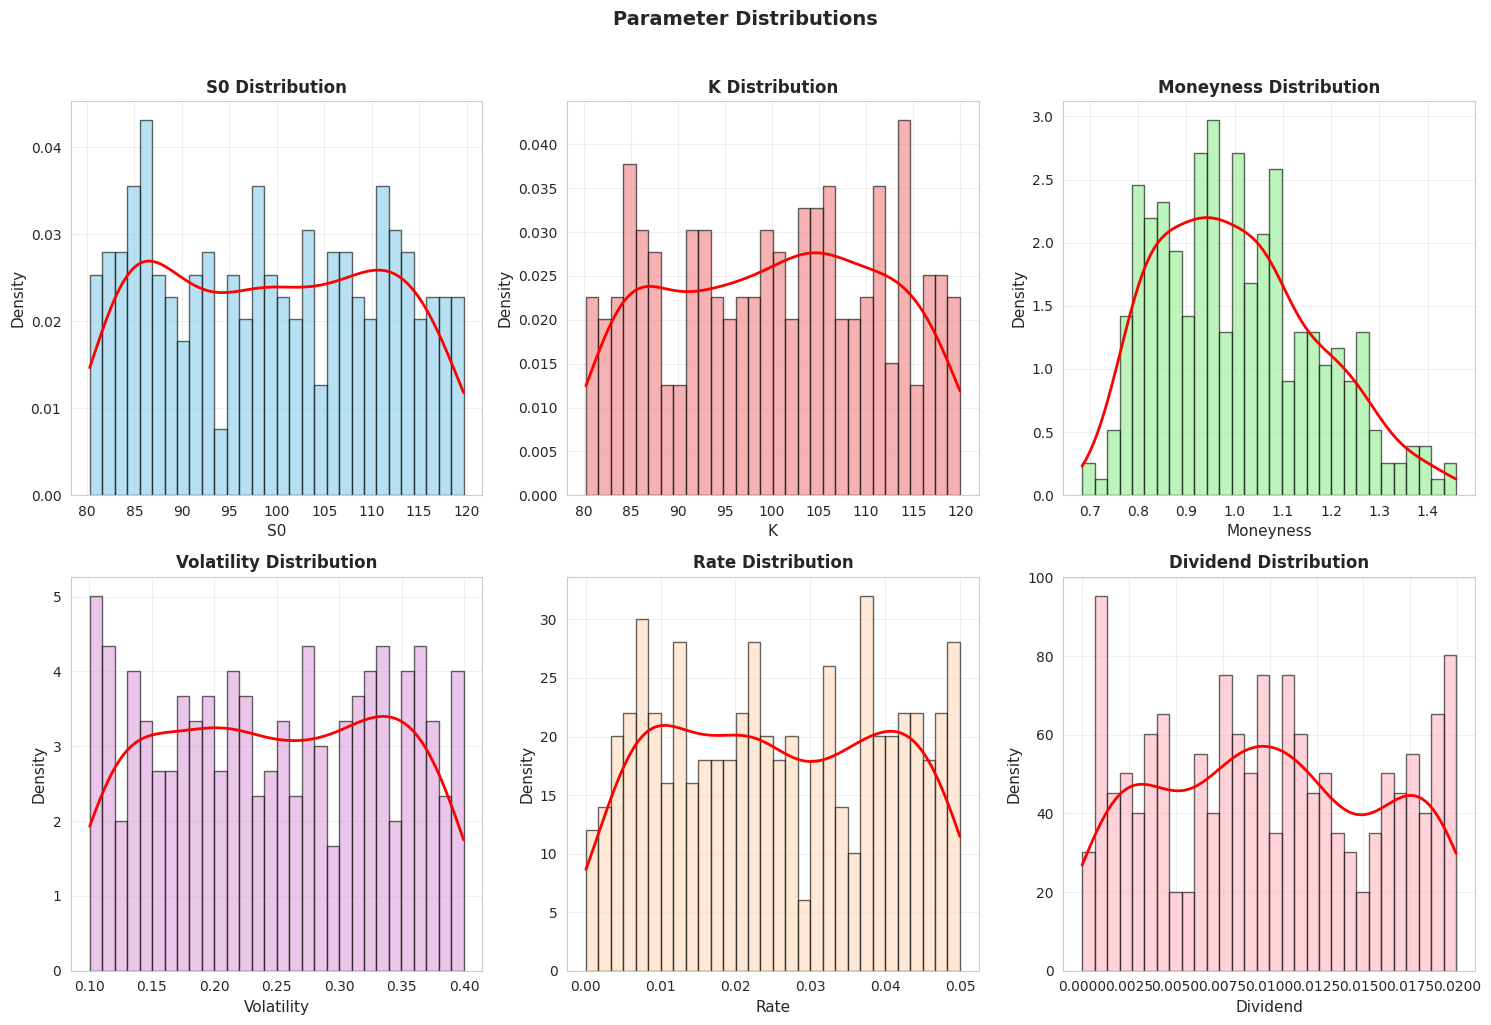

/tmp/ipython-input-2293573486.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Volatility', data=params_df, ax=ax, palette='Set2')


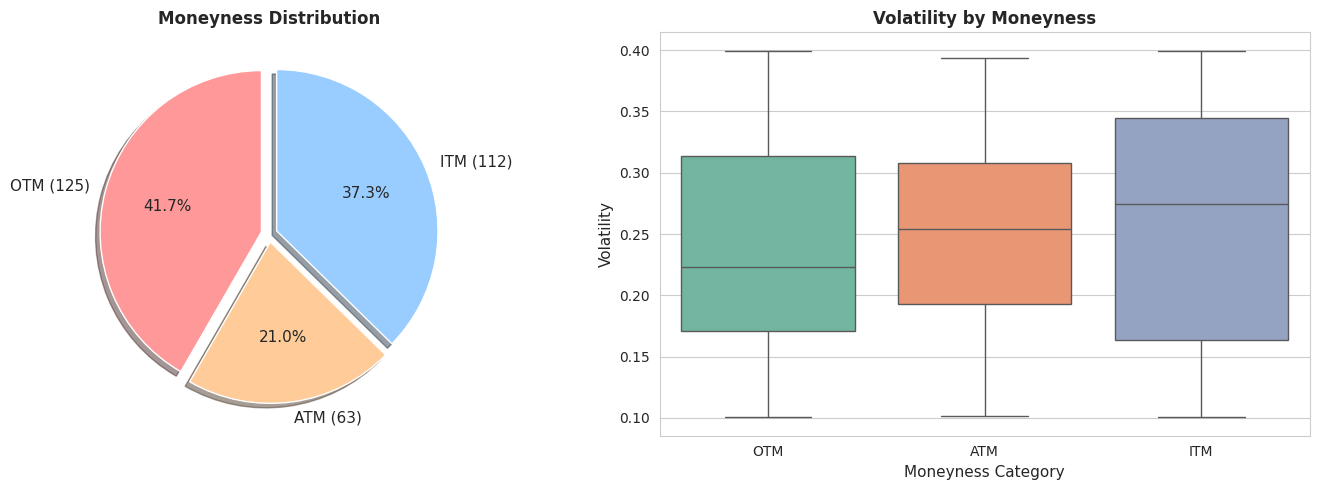

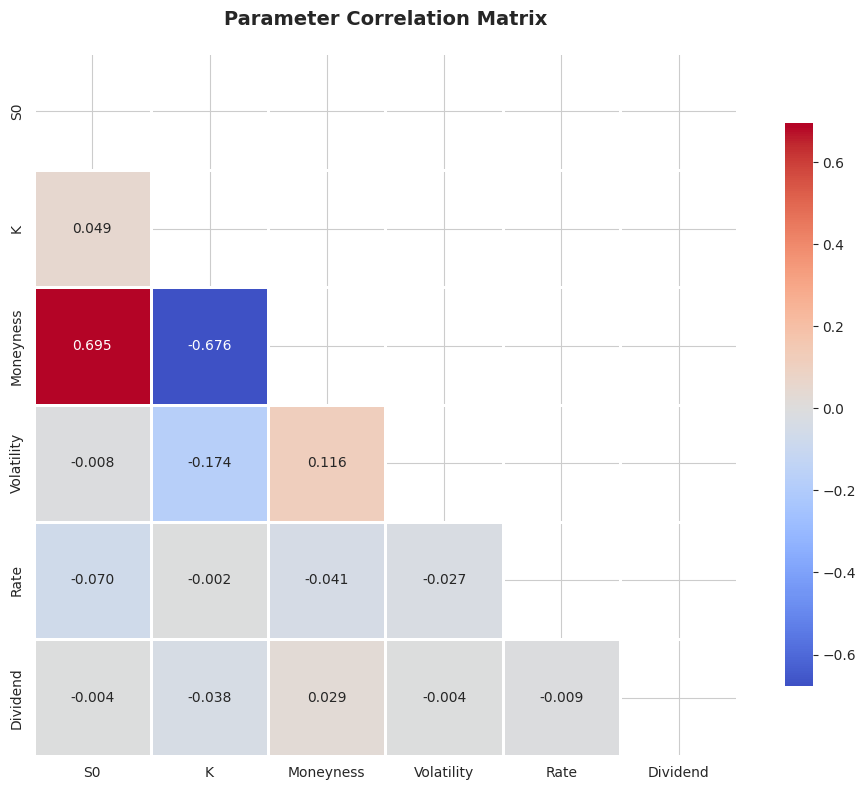

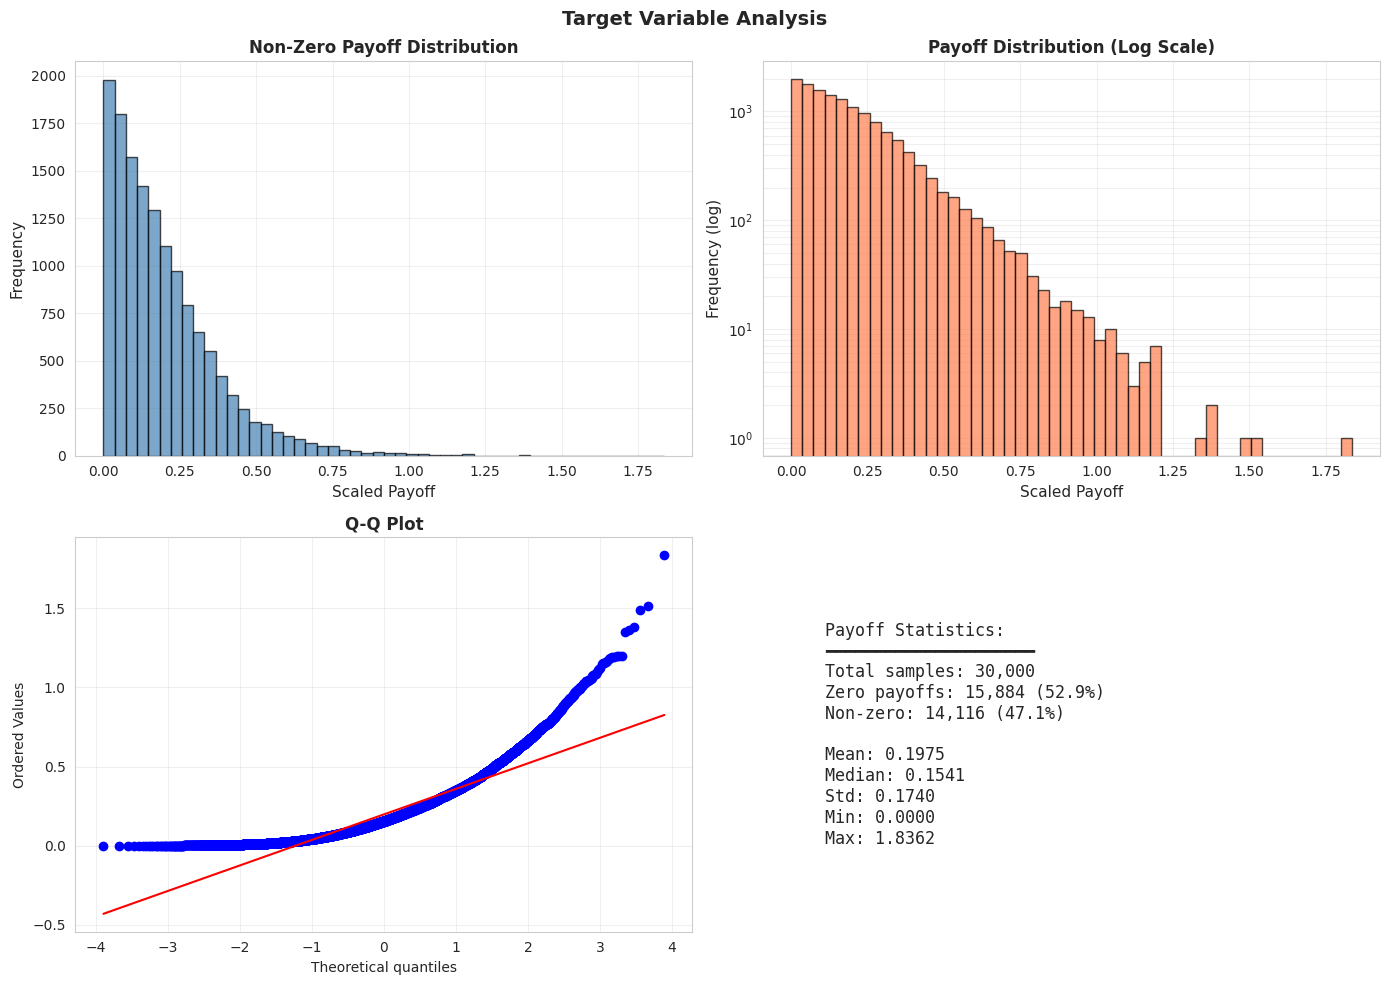


✓ EDA Complete!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# new parameter sample for analysis
S0_arr, K_arr, sigma_arr, r_arr, q_arr, T_arr = sample_regular_params(300, seed=42)

params_df = pd.DataFrame({
    'S0': S0_arr,
    'K': K_arr,
    'Moneyness': S0_arr / K_arr,
    'Volatility': sigma_arr,
    'Rate': r_arr,
    'Dividend': q_arr
})

# 1. distributions of parameters
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

params = ['S0', 'K', 'Moneyness', 'Volatility', 'Rate', 'Dividend']
colors = ['skyblue', 'lightcoral', 'lightgreen', 'plum', 'peachpuff', 'lightpink']

for idx, (param, color) in enumerate(zip(params, colors)):
    ax = axes[idx]
    data = params_df[param]

    ax.hist(data, bins=30, alpha=0.6, color=color, edgecolor='black', density=True)

    # KDE
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 100)
    ax.plot(x_range, kde(x_range), 'r-', linewidth=2)

    ax.set_xlabel(param, fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{param} Distribution', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('Parameter Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 2. Moneyness
moneyness = params_df['Moneyness']
otm = (moneyness < 0.95).sum()
atm = ((moneyness >= 0.95) & (moneyness <= 1.05)).sum()
itm = (moneyness > 1.05).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
ax = axes[0]
sizes = [otm, atm, itm]
labels = [f'OTM ({otm})', f'ATM ({atm})', f'ITM ({itm})']
colors_pie = ['#ff9999', '#ffcc99', '#99ccff']
explode = (0.05, 0.05, 0.05)

ax.pie(sizes, explode=explode, labels=labels, colors=colors_pie, autopct='%1.1f%%',
       shadow=True, startangle=90, textprops={'fontsize': 11})
ax.set_title('Moneyness Distribution', fontsize=12, fontweight='bold')

# Box plot
ax = axes[1]
params_df['Category'] = pd.cut(params_df['Moneyness'],
                                bins=[0, 0.95, 1.05, 2],
                                labels=['OTM', 'ATM', 'ITM'])
sns.boxplot(x='Category', y='Volatility', data=params_df, ax=ax, palette='Set2')
ax.set_xlabel('Moneyness Category', fontsize=11)
ax.set_ylabel('Volatility', fontsize=11)
ax.set_title('Volatility by Moneyness', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# 3. Correlation Heatmap
corr = params_df[['S0', 'K', 'Moneyness', 'Volatility', 'Rate', 'Dividend']].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Parameter Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# 4. Payoff
payoff_scaled = y_all[:, 0]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram
ax = axes[0, 0]
ax.hist(payoff_scaled[payoff_scaled > 0], bins=50, alpha=0.7,
        color='steelblue', edgecolor='black')
ax.set_xlabel('Scaled Payoff', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Non-Zero Payoff Distribution', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# log scale
ax = axes[0, 1]
ax.hist(payoff_scaled[payoff_scaled > 0], bins=50, alpha=0.7,
        color='coral', edgecolor='black')
ax.set_yscale('log')
ax.set_xlabel('Scaled Payoff', fontsize=11)
ax.set_ylabel('Frequency (log)', fontsize=11)
ax.set_title('Payoff Distribution (Log Scale)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, which='both')

# QQ plot
ax = axes[1, 0]
stats.probplot(payoff_scaled[payoff_scaled > 0], dist="norm", plot=ax)
ax.set_title('Q-Q Plot', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# summary statistics
ax = axes[1, 1]
ax.axis('off')
text = f"""
Payoff Statistics:
━━━━━━━━━━━━━━━━━━━━━
Total samples: {len(payoff_scaled):,}
Zero payoffs: {(payoff_scaled == 0).sum():,} ({(payoff_scaled == 0).mean()*100:.1f}%)
Non-zero: {(payoff_scaled > 0).sum():,} ({(payoff_scaled > 0).mean()*100:.1f}%)

Mean: {payoff_scaled[payoff_scaled > 0].mean():.4f}
Median: {np.median(payoff_scaled[payoff_scaled > 0]):.4f}
Std: {payoff_scaled[payoff_scaled > 0].std():.4f}
Min: {payoff_scaled[payoff_scaled > 0].min():.4f}
Max: {payoff_scaled.max():.4f}
"""
ax.text(0.1, 0.5, text, fontsize=12, family='monospace',
        verticalalignment='center')

plt.suptitle('Target Variable Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ EDA Complete!")


## Section 3: Data Interface for Neural Network Training

After generating the full Monte Carlo dataset, we now prepare it for training with **PyTorch**.

### Section 3.1: Custom Dataset Definition

The following class wraps the NumPy arrays into a `torch.utils.data.Dataset` object, allowing efficient batch loading and GPU-based training.

Each element in the dataset contains:
- **Input ($x$):** a normalized price path with an extra $K/S_0$ feature  
  Shape → $(\text{seq\_len\_ext},)$  
- **Output ($y$):** two regression targets  
  - $y_1 = P / K$ — normalized discounted payoff  
  - $y_2 = \partial P / \partial S_0$ — pathwise delta  

This structure supports both **single-task (price)** and **multi-task (price + delta)** learning in subsequent sections.

In [ ]:
# ============================================
# Section 3.1: PyTorch Dataset Class
# ============================================

class PathPayoffDataset(Dataset):
    """
    Custom PyTorch dataset for mapping simulated price paths to
    target payoffs and deltas in a multi-task regression setup.

    Attributes:
        X : torch.FloatTensor of shape (N, seq_len_ext)
            Normalized input paths, each with an appended K/S0 feature.
        y : torch.FloatTensor of shape (N, 2)
            Two regression targets:
                y[..., 0] = discounted payoff / K
                y[..., 1] = pathwise delta (∂P/∂S0)
    """
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()

    def __len__(self) -> int:
        return self.X.shape[0]

    def __getitem__(self, idx: int):
        """
        Return one training example.

        Returns:
            x : torch.Tensor of shape (seq_len_ext,)
            y : torch.Tensor of shape (2,)
        """
        return self.X[idx], self.y[idx]

### Section 3.2: Splitting the Dataset

Once all simulated paths and corresponding payoffs are generated,  
we divide the dataset into **training**, **validation**, and **test** subsets.

This ensures:
- **Training set:** used to update model weights.
- **Validation set:** used to monitor overfitting and trigger early stopping.
- **Test set:** used only for the final evaluation of model performance.

The splitting ratios are set to:
$$
70\% \text{ (train)}, \quad 15\% \text{ (validation)}, \quad 15\% \text{ (test)}.
$$

Random shuffling is applied before splitting to ensure all parameter regions  
are represented across the three subsets, avoiding biased partitions.

In [ ]:
# ============================================
# Section 3.2: Dataset Split (Train / Validation / Test)
# ============================================

def train_val_test_split(
    X: np.ndarray,
    y: np.ndarray,
    train_ratio: float = 0.7,
    val_ratio: float = 0.15,
    shuffle: bool = True,
    seed: int = 42
):
    """
    Split the dataset into training, validation, and test subsets.

    Args:
        X : np.ndarray, shape (N, seq_len_ext)
            Normalized input paths.
        y : np.ndarray, shape (N, 2)
            Corresponding targets (payoff/K, delta).
        train_ratio : float
            Fraction of samples for training (default 0.7).
        val_ratio : float
            Fraction of samples for validation (default 0.15).
            The remaining (1 - train_ratio - val_ratio) is used for testing.
        shuffle : bool
            Whether to randomly shuffle samples before splitting.
        seed : int
            Random seed for reproducibility.

    Returns:
        (X_train, y_train), (X_val, y_val), (X_test, y_test)
    """
    N = X.shape[0]
    if shuffle:
        rng = np.random.default_rng(seed)
        indices = np.arange(N)
        rng.shuffle(indices)
        X, y = X[indices], y[indices]

    n_train = int(N * train_ratio)
    n_val = int(N * val_ratio)

    X_train, y_train = X[:n_train], y[:n_train]
    X_val, y_val = X[n_train:n_train + n_val], y[n_train:n_train + n_val]
    X_test, y_test = X[n_train + n_val:], y[n_train + n_val:]

    return (X_train, y_train), (X_val, y_val), (X_test, y_test)


# Example: Apply to our generated dataset
(X_train, y_train), (X_val, y_val), (X_test, y_test) = train_val_test_split(X_all, y_all)

print("Train size:", X_train.shape[0])
print("Val size:  ", X_val.shape[0])
print("Test size: ", X_test.shape[0])

Train size: 21000
Val size:   4500
Test size:  4500


### Section 3.3: Building DataLoaders

To enable efficient mini-batch training, each subset is wrapped into a  
`torch.utils.data.DataLoader`, which handles shuffling, batching, and parallel I/O.

- **Batch size:** set to 256 (tunable depending on GPU memory).  
- **Shuffling:** applied only to the training loader to improve stochastic optimization.  
- **Validation and test:** kept deterministic for reproducibility.

This completes the **data preprocessing pipeline** — the next section  
will define and train the convolutional neural network (CNN) pricer.

In [ ]:
# ============================================
# Section 3.3: Construct PyTorch DataLoaders
# ============================================

batch_size = 256  # default mini-batch size (can be tuned)

# Create Dataset objects
train_dataset = PathPayoffDataset(X_train, y_train)
val_dataset   = PathPayoffDataset(X_val, y_val)
test_dataset  = PathPayoffDataset(X_test, y_test)

# Wrap datasets with DataLoaders for batch training and evaluation
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# Display batch statistics
print("Number of mini-batches per epoch:")
print(f"  Train: {len(train_loader)}")
print(f"  Val:   {len(val_loader)}")
print(f"  Test:  {len(test_loader)}")

Number of mini-batches per epoch:
  Train: 83
  Val:   18
  Test:  18


## Section 4: Neural Network Architectures for Path-based Pricing

Before introducing convolutional models, we begin with a simple  
**Multi-Layer Perceptron (MLP)** as a baseline.


### Section 4.1: MLP Baseline

The MLP treats each simulated path as a flattened vector input  
and learns a mapping from the normalized path (plus $K/S_0$)  
to two target outputs:
- $y_1 = P / K$ — normalized discounted payoff  
- $y_2 = \partial P / \partial S_0$ — pathwise delta  

Although the MLP ignores sequential dependencies across time,  
it serves as a useful benchmark to compare against convolutional architectures later.

In [ ]:
# ============================================
# Section 4.1: MLP Baseline (Fully Connected Network)
# ============================================

class MLPPathNet(nn.Module):
    """
    Baseline model: a simple Multi-Layer Perceptron (MLP)
    operating on flattened GBM paths.

    Input:
        x : (batch, seq_len_ext)
            Normalized path with appended K/S0 feature.

    Output:
        y : (batch, 2)
            Predicted [discounted payoff/K, delta].
    """
    def __init__(self, seq_len: int, hidden_sizes=(128, 128, 64), dropout: float = 0.1):
        super().__init__()
        layers = []
        in_dim = seq_len

        # Construct hidden layers dynamically
        for h in hidden_sizes:
            layers.extend([
                nn.Linear(in_dim, h),
                nn.ReLU(),
                nn.Dropout(dropout) if dropout > 0.0 else nn.Identity()
            ])
            in_dim = h

        # Final output layer: predicts (price/K, delta)
        layers.append(nn.Linear(in_dim, 2))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through the network.
        """
        return self.net(x)

### Section 4.2: 1D Convolutional Neural Network (CNN)

To capture temporal dependencies along simulated price paths,  
we employ a **1D convolutional neural network (CNN)**.

Unlike the MLP baseline, which treats each path as an unordered vector,  
the CNN processes it as a **time series**, extracting local temporal features  
through successive convolutional layers.

Key characteristics:
- Convolutional blocks with `ReLU` activations and dropout regularization.  
- Global average pooling compresses temporal information.  
- Fully connected head outputs two values:
  - $y_1 = P / K$ (normalized discounted payoff)  
  - $y_2 = \partial P / \partial S_0$ (pathwise delta)

This architecture better captures the dynamics of geometric Brownian motion paths  
and typically achieves lower prediction error than the MLP baseline.

In [ ]:
# ============================================
# Section 4.2: 1D Convolutional Neural Network (CNN) for Path Regression
# ============================================

class CNNPathNet(nn.Module):
    """
    1D-CNN model for path-based pricing of Asian options.

    The network treats each simulated price path as a 1D temporal sequence
    and applies several convolutional layers to extract time-dependent features.

    Input:
        x : (batch_size, seq_len_ext)
            Normalized price paths with appended K/S0 feature.

    Output:
        y : (batch_size, 2)
            Predicted [discounted payoff/K, delta].
    """
    def __init__(
        self,
        seq_len: int,
        num_channels: int = 32,
        fc_hidden: int = 64,
        kernel_size: int = 5,
        dropout: float = 0.1
    ):
        super().__init__()

        # --- Convolutional feature extractor ---
        self.conv1 = nn.Conv1d(1, num_channels, kernel_size, padding=kernel_size // 2)
        self.conv2 = nn.Conv1d(num_channels, num_channels, kernel_size, padding=kernel_size // 2)
        self.conv3 = nn.Conv1d(num_channels, num_channels, kernel_size, padding=kernel_size // 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        # --- Fully connected prediction head ---
        self.fc1 = nn.Linear(num_channels, fc_hidden)
        self.fc2 = nn.Linear(fc_hidden, 2)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through the CNN.
        Args:
            x : (batch_size, seq_len_ext)
        Returns:
            y : (batch_size, 2)
        """
        # Add channel dimension for Conv1D layers
        x = x.unsqueeze(1)  # -> (batch, 1, seq_len)

        # Convolutional layers
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        x = self.dropout(x)

        # Global average pooling over time dimension
        x = x.mean(dim=2)  # -> (batch, num_channels)

        # Fully connected layers
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)  # -> (batch, 2)

        return x

### Section 4.3: LSTM-Based Neural Network

To further explore temporal modeling, we implement a  
**Long Short-Term Memory (LSTM)** network as an alternative to the CNN.

The LSTM explicitly models sequential dependencies along the path:
- Input sequence: normalized price trajectory $(S_t / K)$.
- The final hidden state summarizes the temporal evolution.
- Fully connected layers map the hidden representation to two outputs:
  - $y_1 = P / K$ (normalized discounted payoff)
  - $y_2 = \partial P / \partial S_0$ (pathwise delta)

Compared to the CNN:
- The **CNN** captures local temporal patterns via convolution.  
- The **LSTM** captures longer-term temporal dependencies via recurrent memory.

Both architectures will later be compared empirically in terms of
prediction accuracy and training efficiency.

In [ ]:
# ============================================
# Section 4.3: LSTM Model for Path-based Pricing
# ============================================

class LSTMPathNet(nn.Module):
    """
    LSTM-based neural network for path-to-payoff regression.

    The model processes the simulated GBM path as a sequential input,
    using recurrent dynamics to encode temporal dependencies in price evolution.

    Input:
        x : (batch_size, seq_len_ext)
            Normalized path with appended K/S0 feature.

    Output:
        y : (batch_size, 2)
            Predicted [discounted payoff/K, delta].
    """
    def __init__(
        self,
        input_size: int = 1,
        hidden_size: int = 64,
        num_layers: int = 1,
        fc_hidden: int = 64,
        dropout: float = 0.1
    ):
        super().__init__()

        # --- Sequential feature extractor ---
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True  # expects (batch, seq_len, input_size)
        )

        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

        # --- Prediction head ---
        self.fc1 = nn.Linear(hidden_size, fc_hidden)
        self.fc2 = nn.Linear(fc_hidden, 2)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through the LSTM-based model.
        """
        # Add feature dimension → (batch, seq_len, 1)
        x = x.unsqueeze(-1)

        # LSTM output and hidden states
        lstm_out, (h_n, c_n) = self.lstm(x)

        # Use the final hidden state from the last LSTM layer
        h_last = h_n[-1]  # shape: (batch, hidden_size)

        # Fully connected prediction head
        h = self.relu(self.fc1(h_last))
        h = self.dropout(h)
        out = self.fc2(h)  # (batch, 2)

        return out

### Section 4.4: CNN-LSTM Neural Network

To combine local patterns and long-term memory, we use a  
**Convolutional Long Short-Term Memory (CNN-LSTM)** network.

The CNN-LSTM works on the whole simulated price path:

- **Input sequence:** normalized price path \((S_t / K)\).
- **CNN layers** first extract local short-term patterns along the path.
- **LSTM layer** then reads the sequence of CNN features and keeps long-term information.
- The final hidden state of the LSTM is a summary of the whole path.
- Fully connected layers map this summary to two outputs:
  - \(y_1 = P / K\) (normalized discounted payoff),
  - \(y_2 = \partial P / \partial S_0\) (pathwise delta).

Compared to the basic CNN:

- The **CNN** alone focuses on local patterns in a small window.
- The **LSTM** part adds memory of the full time history.
- The **CNN-LSTM** therefore uses both local features (from CNN) and long-range dependence (from LSTM).

Later we compare the CNN-LSTM with the pure CNN and the TCN  
in terms of pricing accuracy and training time.


In [ ]:
class CNN_LSTM_PathNet(nn.Module):

    def __init__(self, seq_len, cnn_channels=32, lstm_hidden_size=64, num_layers=2, kernel_size=5, dropout=0.1):
        super().__init__()

        self.conv1 = nn.Conv1d(in_channels=1, out_channels=cnn_channels, kernel_size=kernel_size, padding='same')
        self.conv2 = nn.Conv1d(in_channels=cnn_channels, out_channels=cnn_channels, kernel_size=kernel_size, padding='same')

        self.lstm = nn.LSTM(input_size=cnn_channels,
                             hidden_size=lstm_hidden_size,
                             num_layers=num_layers,
                             batch_first=True,
                             dropout=dropout)

        self.dropout = nn.Dropout(dropout)

        self.fc_out = nn.Linear(lstm_hidden_size + 2, 1)

    def forward(self, x):
        """
        Args:
            x: tensor of shape (batch_size, seq_len)
        Returns:
            out: tensor of shape (batch_size, 1)
        """

        path_mean = x.mean(dim=1).unsqueeze(1)
        path_std = x.std(dim=1).unsqueeze(1)

        # Input shape (B, L) -> (B, 1, L)
        x_cnn = x.unsqueeze(1)

        # (B, 1, L) -> (B, C, L)
        x_cnn = F.relu(self.conv1(x_cnn))
        x_cnn = F.relu(self.conv2(x_cnn))

        x_lstm = x_cnn.transpose(1, 2)

        # lstm_out shape: (B, L, H_out)
        # h_n shape: (num_layers, B, H_out)
        lstm_out, (h_n, c_n) = self.lstm(x_lstm)

        h_last_layer = h_n[-1, :, :] # (B, H_out)

        combined_features = torch.cat((h_last_layer, path_mean, path_std), dim=1) # (B, H_out + 2)

        combined_features = self.dropout(combined_features)
        out = self.fc_out(combined_features)

        return out

### Section 4.5: TCN Neural Network

To model long-range time dependence with only convolutions,  
we also use a **Temporal Convolutional Network (TCN)**.

The TCN processes the normalized price trajectory as a 1D time series:

- **Input sequence:** normalized price path \((S_t / K)\).
- **Dilated 1D convolutions** give a large receptive field, so the model can see far back in time.
- **Residual blocks** (skip connections) make training stable and allow deeper networks.
- Global average pooling over time gives one feature vector for each path.
- Fully connected layers map this vector to two outputs:
  - \(y_1 = P / K\) (normalized discounted payoff),
  - \(y_2 = \partial P / \partial S_0\) (pathwise delta).

Compared to other models:

- The **CNN** captures local patterns but has a limited receptive field.
- The **LSTM** captures long-term memory but is more expensive to train.
- The **TCN** keeps the speed of convolutions while still modeling long-range dependence  
  through dilation and residual connections.

We will later compare the TCN with the CNN and the CNN-LSTM  
using the same datasets and evaluation metrics.


In [ ]:
### TCN Components (CORRECTED) ###
class TCNBlock(nn.Module):
    """
    TCN Residual Block with Dilated Causal Convolution (CORRECTED).
    Uses F.pad to manually apply left-side causal padding and preserve sequence length.
    """
    def __init__(self, in_channels, out_channels, kernel_size, stride, dilation, padding, dropout=0.1):
        super(TCNBlock, self).__init__()

        # 'padding' argument is the amount of left-side padding needed: (kernel_size - 1) * dilation
        self.padding_amount = padding

        # 1. First convolutional layer: padding=0 because we manually pad in forward()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size,
                               stride=stride, padding=0, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        # 2. Second convolutional layer: padding=0
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size,
                               stride=stride, padding=0, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        # Residual connection
        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None
        self.relu = nn.ReLU()
        self.init_weights()

    def init_weights(self):
        self.conv1.weight.data.normal_(0, 0.01)
        self.conv2.weight.data.normal_(0, 0.01)
        if self.downsample is not None:
            self.downsample.weight.data.normal_(0, 0.01)

    def forward(self, x):
        # Store input for residual connection
        res = x if self.downsample is None else self.downsample(x)

        # 1. First layer
        # F.pad format: (pad_left, pad_right) for the last dimension (L)
        out = F.pad(x, (self.padding_amount, 0), mode='constant', value=0.0)
        out = self.conv1(out)

        out = self.bn1(out)
        out = self.relu1(out)
        out = self.dropout1(out)

        # 2. Second layer
        out = F.pad(out, (self.padding_amount, 0), mode='constant', value=0.0)
        out = self.conv2(out)

        out = self.bn2(out)
        out = self.relu2(out)
        out = self.dropout2(out)

        # Residual connection: out (B, C, 51) + res (B, C, 51)
        return self.relu(out + res)


class TCNPathNet(nn.Module):
    """
    Temporal Convolutional Network for path -> payoff regression.
    (This part remains largely the same, just included for completeness)
    """
    def __init__(self, seq_len, num_channels=(32, 64, 128), kernel_size=3, dropout=0.1):
        super(TCNPathNet, self).__init__()

        layers = []
        in_channels = 1 # Input channel is 1 (the price path)
        for i, out_channels in enumerate(num_channels):
            dilation_size = 2 ** i
            padding = (kernel_size - 1) * dilation_size
            layers += [TCNBlock(in_channels, out_channels, kernel_size, stride=1,
                                dilation=dilation_size, padding=padding, dropout=dropout)]
            in_channels = out_channels

        self.network = nn.Sequential(*layers)

        # Final layers
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc_out = nn.Linear(num_channels[-1], 1)
        self.dropout_out = nn.Dropout(dropout)

    def forward(self, x):
        # Add channel dimension: (batch, 1, seq_len)
        x = x.unsqueeze(1)

        # TCN layers
        x = self.network(x)

        # Global Average Pooling
        x = self.avg_pool(x).squeeze(-1) # -> (batch, num_channels[-1])

        # Final FC layer
        x = self.dropout_out(x)
        out = self.fc_out(x)

        return out

### Section 4.6: Model Initialization

This section instantiates all three neural network architectures introduced earlier:

| Model | Core Idea | Temporal Awareness | Expected Strength |
|:------|:-----------|:-------------------|:------------------|
| **MLP** | Fully connected network on flattened paths | None | Simple and fast baseline |
| **CNN** | 1D convolutions across time steps | Local temporal patterns | Efficient feature extraction |
| **LSTM** | Recurrent sequence encoder | Long-term memory | Captures sequential dependencies |

Each model outputs two targets—normalized discounted payoff and pathwise delta—and  
will later be trained under identical conditions for fair comparison.

All models are moved to the selected computing device (`CPU` or `GPU`) before training.

In [ ]:
# ============================================
# Section 4.4: Instantiate All Model Architectures
# ============================================

# Ensure model classes are defined
try:
    MLPPathNet, CNNPathNet, LSTMPathNet
except NameError as e:
    raise RuntimeError(
        "Missing one or more model definitions. "
        "Please make sure Sections 4.1–4.3 have been executed before running this cell."
    ) from e

# Ensure device exists
try:
    device
except NameError:
    import torch
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device auto-set to:", device)

seq_len = X_all.shape[1]

# Instantiate models
mlp_model = MLPPathNet(seq_len, (128, 128, 64), 0.1).to(device)
cnn_model = CNNPathNet(seq_len, 32, 64, 5, 0.1).to(device)
lstm_model = LSTMPathNet(1, 64, 1, 64, 0.1).to(device)

cnn_lstm_model = CNN_LSTM_PathNet(seq_len=seq_len,
                       cnn_channels=64,
                       lstm_hidden_size=64,
                       num_layers=2,
                       kernel_size=5,
                       dropout=0.1).to(device)
tcn_model = TCNPathNet(seq_len=seq_len,
                       num_channels=(32, 64, 128),
                       kernel_size=3,
                       dropout=0.1).to(device)

# Display summary
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=== Model Summaries ===")
print(f"MLP  : {count_parameters(mlp_model):,} trainable parameters")
print(f"CNN  : {count_parameters(cnn_model):,} trainable parameters")
print(f"LSTM : {count_parameters(lstm_model):,} trainable parameters")
print(f"CNN-LSTM : {count_parameters(cnn_lstm_model):,} trainable parameters")
print(f"TCN : {count_parameters(tcn_model):,} trainable parameters")

Device auto-set to: cpu
=== Model Summaries ===
MLP  : 31,682 trainable parameters
CNN  : 12,738 trainable parameters
LSTM : 21,442 trainable parameters
CNN-LSTM : 87,555 trainable parameters
TCN : 107,297 trainable parameters


# Section 5: Training Utilities and Optimization Setup

This section introduces the essential components required for training neural‐network–based pricers:

1. **Loss Function** — measures how well the model reproduces the target payoff and delta.  
   We use Mean Squared Error (MSE) across both outputs, a simple yet effective metric for regression tasks.

2. **Optimizer Builder** — provides a consistent way to construct an Adam optimizer with configurable
   learning rate and optional L2 regularization.

Later sections (5.2 and 5.3) will define the full training loop, validation monitoring, and early‐stopping logic.

## Section 5.1 – Loss Function and Optimizer Builder  

This subsection defines the **training objective** and the **optimizer**.  
We use a standard **Mean Squared Error (MSE)** loss for both outputs (normalized price and delta),  
and the **Adam** optimizer for stable and efficient gradient updates.

In [ ]:
# Section 5.1: Loss function & optimizer builder

def build_optimizer(model, lr=1e-3, weight_decay=0.0):
    """
    Build an Adam optimizer for the given model.
    """
    return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

criterion = nn.MSELoss()

## Section 5.2 – Regression Metrics  

This subsection defines evaluation metrics for model performance.  
We compute **Mean Absolute Error (MAE)** and **Root Mean Squared Error (RMSE)**  
to quantify prediction accuracy for payoff and delta outputs.

In [ ]:
# Section 5.2: Metrics for regression

def compute_metrics(y_pred, y_true):
    """
    Computes MAE and RMSE for regression outputs.
    Args:
        y_pred: tensor of shape (N,)
        y_true: tensor of shape (N,)
    """
    mae = torch.mean(torch.abs(y_pred - y_true)).item()
    rmse = torch.sqrt(torch.mean((y_pred - y_true)**2)).item()
    return mae, rmse


## Section 5.3 – Model Training Loop  

This subsection implements a **general training function** for both MLP and CNN models.  
It performs standard supervised learning with **MSE loss** and **Adam optimization**,  
tracks training/validation loss, and uses **early stopping** to prevent overfitting.

In [ ]:
# Section 5.3: General training function for MLP/CNN

def train_one_model(model, train_loader, val_loader,
                    num_epochs=30, lr=1e-3, patience=5):
    """
    Train a PyTorch model on the path → payoff task.

    Args:
        model: PyTorch model (MLP or CNN)
        train_loader: DataLoader for training
        val_loader: DataLoader for validation
        num_epochs: max number of epochs
        lr: learning rate for Adam
        patience: early stopping patience

    Returns:
        best_model_state: state_dict of the best model
        history: dict with train/val loss curves
    """
    optimizer = build_optimizer(model, lr=lr)

    best_val_loss = float("inf")
    best_state = None
    no_improve = 0

    history = {"train_loss": [], "val_loss": []}

    for epoch in range(num_epochs):

        # ----- Training -----
        model.train()
        train_losses = []

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            preds = model(x)
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        avg_train_loss = np.mean(train_losses)

        # ----- Validation -----
        model.eval()
        val_losses = []

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                y = y.to(device)
                preds = model(x)
                val_loss = criterion(preds, y)
                val_losses.append(val_loss.item())

        avg_val_loss = np.mean(val_losses)

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"train_loss={avg_train_loss:.6f} | val_loss={avg_val_loss:.6f}")

        # ----- Early stopping check -----
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state = model.state_dict()
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print("Early stopping triggered!")
                break

    return best_state, history


## Section 5.4 – Model Trainings

### Section 5.4.1 – Train MLP Model  

In [ ]:
# Section 5.4: Train MLP model

mlp_model = MLPPathNet(seq_len).to(device)

best_mlp_state, mlp_history = train_one_model(
    mlp_model,
    train_loader,
    val_loader,
    num_epochs=40,
    lr=1e-3,
    patience=6
)

# Load best model weights
mlp_model.load_state_dict(best_mlp_state)


Epoch 1/40 | train_loss=0.100391 | val_loss=0.049105
Epoch 2/40 | train_loss=0.044015 | val_loss=0.032249
Epoch 3/40 | train_loss=0.032333 | val_loss=0.020177
Epoch 4/40 | train_loss=0.023192 | val_loss=0.014143
Epoch 5/40 | train_loss=0.018765 | val_loss=0.011552
Epoch 6/40 | train_loss=0.017417 | val_loss=0.010528
Epoch 7/40 | train_loss=0.015496 | val_loss=0.012335
Epoch 8/40 | train_loss=0.014395 | val_loss=0.026998
Epoch 9/40 | train_loss=0.017956 | val_loss=0.023033
Epoch 10/40 | train_loss=0.013415 | val_loss=0.014247
Epoch 11/40 | train_loss=0.013609 | val_loss=0.009255
Epoch 12/40 | train_loss=0.012444 | val_loss=0.015824
Epoch 13/40 | train_loss=0.011780 | val_loss=0.023167
Epoch 14/40 | train_loss=0.011916 | val_loss=0.008819
Epoch 15/40 | train_loss=0.011113 | val_loss=0.022003
Epoch 16/40 | train_loss=0.013263 | val_loss=0.006764
Epoch 17/40 | train_loss=0.012670 | val_loss=0.008755
Epoch 18/40 | train_loss=0.014375 | val_loss=0.008413
Epoch 19/40 | train_loss=0.010438 | v

<All keys matched successfully>

### Section 5.4.2: Train CNN model

In [ ]:
# Section 5.5: Train CNN model

cnn_model = CNNPathNet(seq_len).to(device)

best_cnn_state, cnn_history = train_one_model(
    cnn_model,
    train_loader,
    val_loader,
    num_epochs=40,
    lr=1e-3,
    patience=6
)

cnn_model.load_state_dict(best_cnn_state)


Epoch 1/40 | train_loss=0.102601 | val_loss=0.041576
Epoch 2/40 | train_loss=0.035679 | val_loss=0.024946
Epoch 3/40 | train_loss=0.022823 | val_loss=0.023709
Epoch 4/40 | train_loss=0.019726 | val_loss=0.019254
Epoch 5/40 | train_loss=0.018355 | val_loss=0.025580
Epoch 6/40 | train_loss=0.019125 | val_loss=0.015370
Epoch 7/40 | train_loss=0.017028 | val_loss=0.012235
Epoch 8/40 | train_loss=0.016379 | val_loss=0.016554
Epoch 9/40 | train_loss=0.016707 | val_loss=0.020210
Epoch 10/40 | train_loss=0.016700 | val_loss=0.012655
Epoch 11/40 | train_loss=0.015198 | val_loss=0.011969
Epoch 12/40 | train_loss=0.015035 | val_loss=0.010742
Epoch 13/40 | train_loss=0.014551 | val_loss=0.012826
Epoch 14/40 | train_loss=0.014315 | val_loss=0.010497
Epoch 15/40 | train_loss=0.013936 | val_loss=0.013996
Epoch 16/40 | train_loss=0.014702 | val_loss=0.011251
Epoch 17/40 | train_loss=0.014279 | val_loss=0.009555
Epoch 18/40 | train_loss=0.013291 | val_loss=0.011877
Epoch 19/40 | train_loss=0.013264 | v

<All keys matched successfully>

### Section 5.4.3: Train LSTM model

In [ ]:
# Section 5.6: Train LSTM model

lstm_model = LSTMPathNet(
    input_size=1,
    hidden_size=64,
    num_layers=1,
    fc_hidden=64,
    dropout=0.1
).to(device)

best_lstm_state, lstm_history = train_one_model(
    lstm_model,
    train_loader,
    val_loader,
    num_epochs=40,
    lr=1e-3,
    patience=6
)

lstm_model.load_state_dict(best_lstm_state)

Epoch 1/40 | train_loss=0.130231 | val_loss=0.030767
Epoch 2/40 | train_loss=0.026157 | val_loss=0.018178
Epoch 3/40 | train_loss=0.018946 | val_loss=0.013557
Epoch 4/40 | train_loss=0.016036 | val_loss=0.041649
Epoch 5/40 | train_loss=0.017689 | val_loss=0.016705
Epoch 6/40 | train_loss=0.013732 | val_loss=0.010853
Epoch 7/40 | train_loss=0.012109 | val_loss=0.010412
Epoch 8/40 | train_loss=0.012652 | val_loss=0.008462
Epoch 9/40 | train_loss=0.010674 | val_loss=0.016117
Epoch 10/40 | train_loss=0.011574 | val_loss=0.012304
Epoch 11/40 | train_loss=0.012120 | val_loss=0.009221
Epoch 12/40 | train_loss=0.011306 | val_loss=0.011108
Epoch 13/40 | train_loss=0.009559 | val_loss=0.024002
Epoch 14/40 | train_loss=0.012295 | val_loss=0.011560
Early stopping triggered!


<All keys matched successfully>

### Section 5.4.4: Train CNN-LSTM model

In [ ]:
best_cnn_lstm_state, cnn_lstm_history = train_one_model(
    cnn_lstm_model, train_loader, val_loader,
    num_epochs=40, lr=1e-3, patience=6
)
cnn_lstm_model.load_state_dict(best_cnn_lstm_state)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([256, 2])) that is different to the input size (torch.Size([256, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([8, 2])) that is different to the input size (torch.Size([8, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([148, 2])) that is different to the input size (torch.Size([148, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_

Epoch 1/40 | train_loss=0.132161 | val_loss=0.101273
Epoch 2/40 | train_loss=0.099875 | val_loss=0.103704
Epoch 3/40 | train_loss=0.098724 | val_loss=0.099054
Epoch 4/40 | train_loss=0.099181 | val_loss=0.096717
Epoch 5/40 | train_loss=0.096156 | val_loss=0.105325
Epoch 6/40 | train_loss=0.096578 | val_loss=0.098616
Epoch 7/40 | train_loss=0.096197 | val_loss=0.110062
Epoch 8/40 | train_loss=0.097210 | val_loss=0.094533
Epoch 9/40 | train_loss=0.094858 | val_loss=0.095112
Epoch 10/40 | train_loss=0.095834 | val_loss=0.100341
Epoch 11/40 | train_loss=0.094940 | val_loss=0.094485
Epoch 12/40 | train_loss=0.094557 | val_loss=0.099586
Epoch 13/40 | train_loss=0.095681 | val_loss=0.097126
Epoch 14/40 | train_loss=0.093942 | val_loss=0.093402
Epoch 15/40 | train_loss=0.093568 | val_loss=0.095632
Epoch 16/40 | train_loss=0.094298 | val_loss=0.096615
Epoch 17/40 | train_loss=0.094319 | val_loss=0.093193
Epoch 18/40 | train_loss=0.095562 | val_loss=0.093454
Epoch 19/40 | train_loss=0.094381 | v

<All keys matched successfully>

### Section 5.4.5: Train TCN model

In [ ]:
# 5.5.2 Train TCN model

tcn_model = TCNPathNet(seq_len).to(device)

best_tcn_state, tcn_history = train_one_model(
    tcn_model, train_loader, val_loader,
    num_epochs=40, lr=1e-3, patience=6
)

tcn_model.load_state_dict(best_tcn_state)

Epoch 1/40 | train_loss=0.129849 | val_loss=0.103807
Epoch 2/40 | train_loss=0.104092 | val_loss=0.100273
Epoch 3/40 | train_loss=0.103421 | val_loss=0.105499
Epoch 4/40 | train_loss=0.102304 | val_loss=0.099765
Epoch 5/40 | train_loss=0.101088 | val_loss=0.099590
Epoch 6/40 | train_loss=0.102128 | val_loss=0.099863
Epoch 7/40 | train_loss=0.102617 | val_loss=0.103971
Epoch 8/40 | train_loss=0.098828 | val_loss=0.100153
Epoch 9/40 | train_loss=0.100082 | val_loss=0.097242
Epoch 10/40 | train_loss=0.099681 | val_loss=0.100888
Epoch 11/40 | train_loss=0.099183 | val_loss=0.120866
Epoch 12/40 | train_loss=0.100071 | val_loss=0.098092
Epoch 13/40 | train_loss=0.100284 | val_loss=0.098801
Epoch 14/40 | train_loss=0.100733 | val_loss=0.096962
Epoch 15/40 | train_loss=0.099557 | val_loss=0.097012
Epoch 16/40 | train_loss=0.098508 | val_loss=0.102529
Epoch 17/40 | train_loss=0.098146 | val_loss=0.097444
Epoch 18/40 | train_loss=0.099090 | val_loss=0.097625
Epoch 19/40 | train_loss=0.099843 | v

<All keys matched successfully>

## Section 5.5 – Model Evaluation on Test Set  

After training, each model (MLP, CNN, and LSTM) is evaluated on the **held-out test set**.  
We compute **Mean Absolute Error (MAE)** and **Root Mean Squared Error (RMSE)**  
to compare their generalization performance on unseen simulated paths.

In [ ]:
# Section 5.5: Evaluate the trained models on test set

def evaluate_model(model, test_loader):
    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device)
            preds = model(x)
            all_preds.append(preds.cpu())
            all_targets.append(y.cpu())

    all_preds = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)

    mae, rmse = compute_metrics(all_preds, all_targets)
    return mae, rmse


mlp_mae, mlp_rmse = evaluate_model(mlp_model, test_loader)
cnn_mae, cnn_rmse = evaluate_model(cnn_model, test_loader)
lstm_mae, lstm_rmse = evaluate_model(lstm_model, test_loader)
cnn_lstm_mae, cnn_lstm_rmse = evaluate_model(cnn_lstm_model, test_loader)
tcn_mae, tcn_rmse = evaluate_model(tcn_model, test_loader)

print("\n===== Test Set Performance =====")
print(f"MLP   : MAE = {mlp_mae:.6f}, RMSE = {mlp_rmse:.6f}")
print(f"CNN   : MAE = {cnn_mae:.6f}, RMSE = {cnn_rmse:.6f}")
print(f"LSTM  : MAE = {lstm_mae:.6f}, RMSE = {lstm_rmse:.6f}")
print(f"CNN_LSTM  : MAE = {cnn_lstm_mae:.6f}, RMSE = {cnn_lstm_rmse:.6f}")
print(f"TCN  : MAE = {tcn_mae:.6f}, RMSE = {tcn_rmse:.6f}")


===== Test Set Performance =====
MLP   : MAE = 0.025573, RMSE = 0.085980
CNN   : MAE = 0.042040, RMSE = 0.105967
LSTM  : MAE = 0.040685, RMSE = 0.106513
CNN_LSTM  : MAE = 0.200274, RMSE = 0.305789
TCN  : MAE = 0.213700, RMSE = 0.306499



Section 5.8: Prediction Quality Analysis


/tmp/ipython-input-3226865556.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Error', data=error_df, ax=ax, palette='Set2')


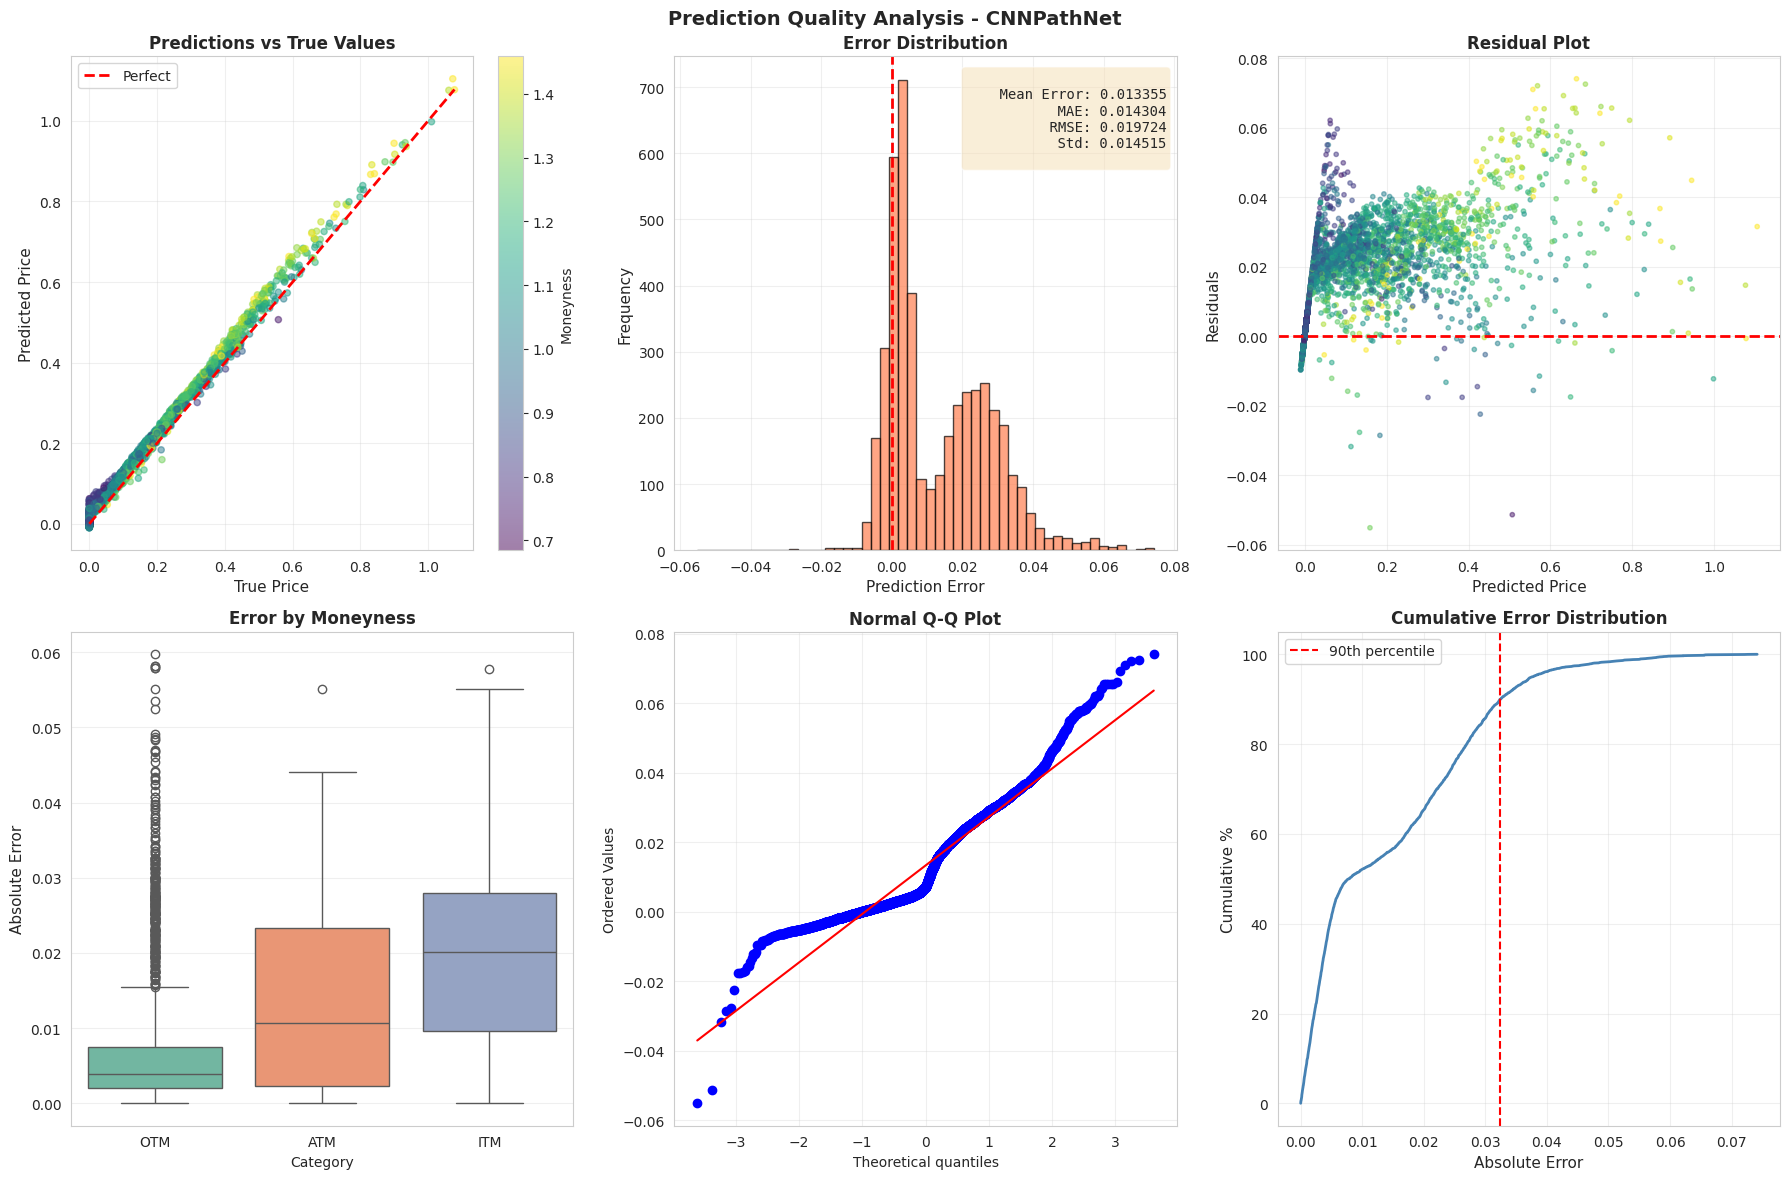


Prediction Quality Statistics:
MAE:  0.014304
RMSE: 0.019724
Max Error: 0.074155
90th Percentile: 0.032461


/tmp/ipython-input-3226865556.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Error', data=error_df, ax=ax, palette='Set2')


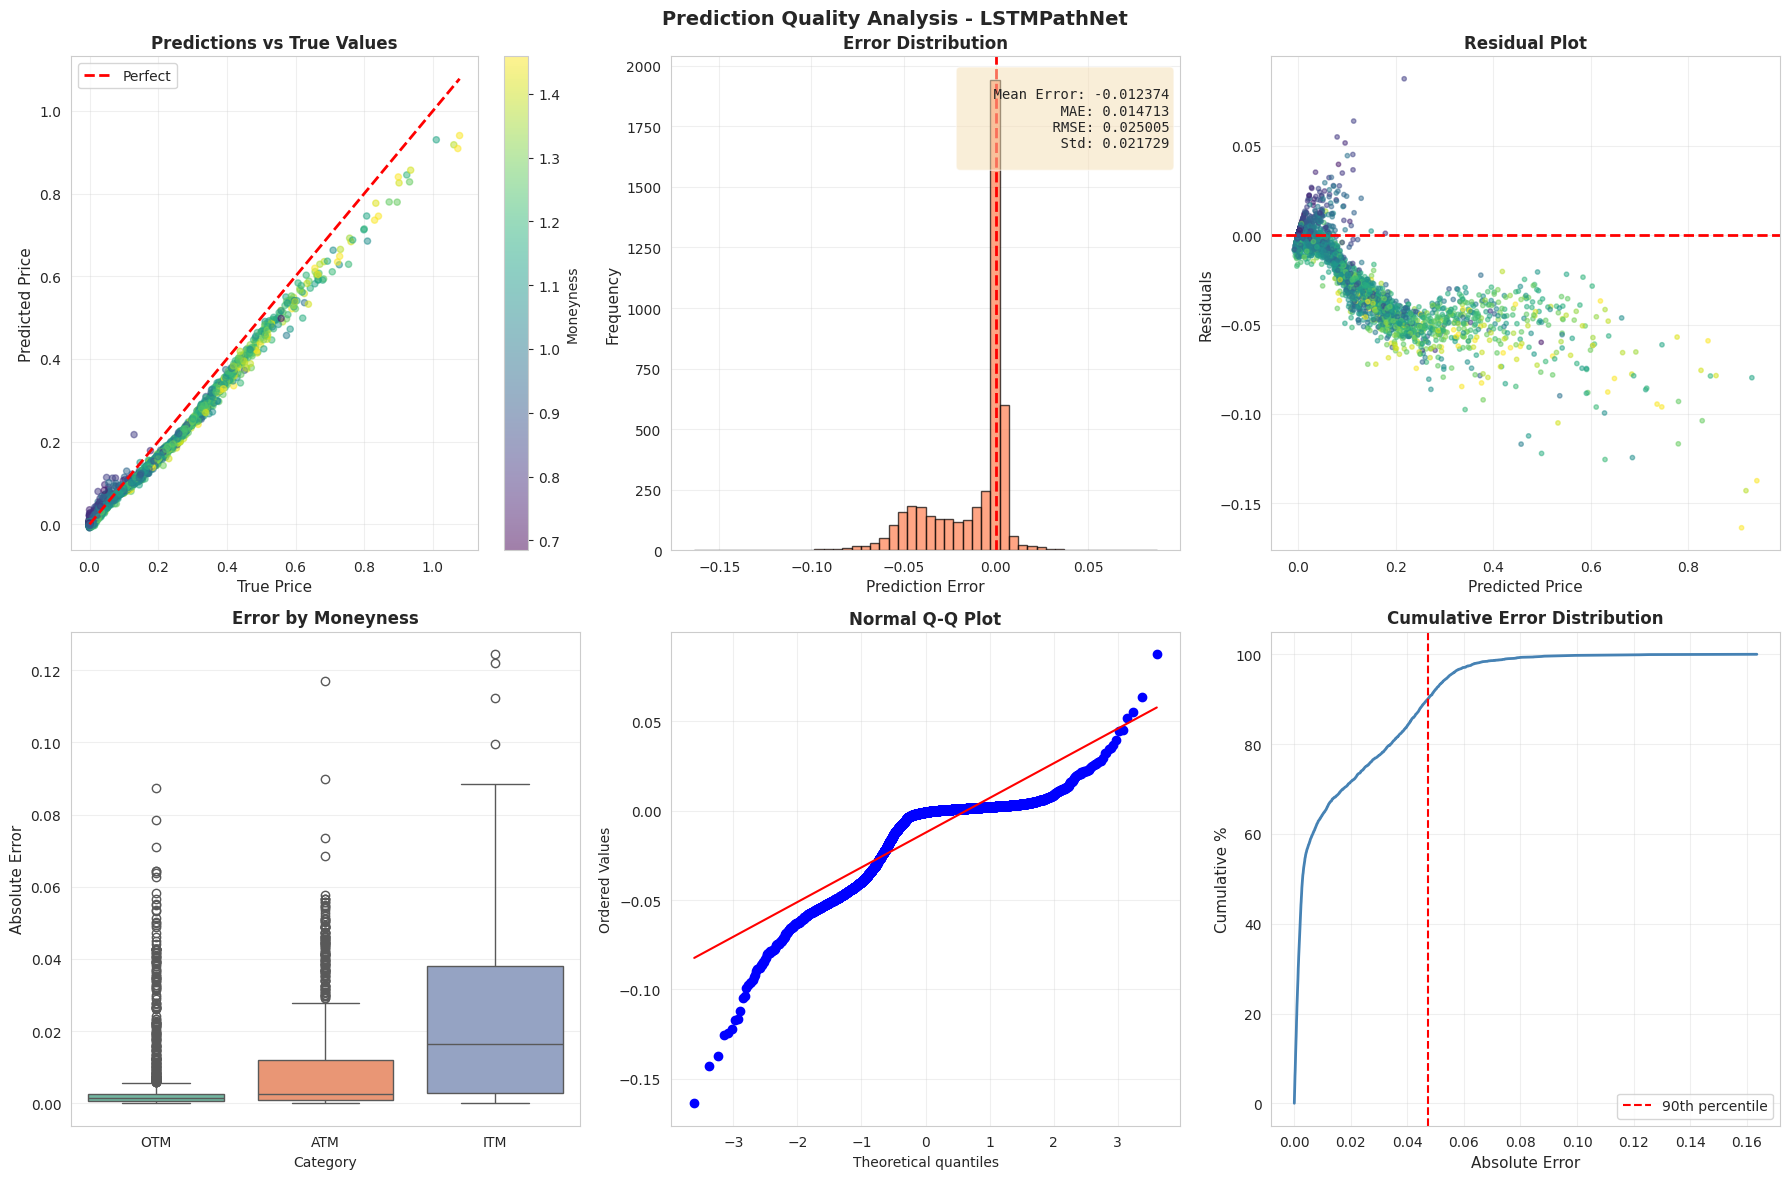


Prediction Quality Statistics:
MAE:  0.014713
RMSE: 0.025005
Max Error: 0.163612
90th Percentile: 0.047225


/tmp/ipython-input-3226865556.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Error', data=error_df, ax=ax, palette='Set2')


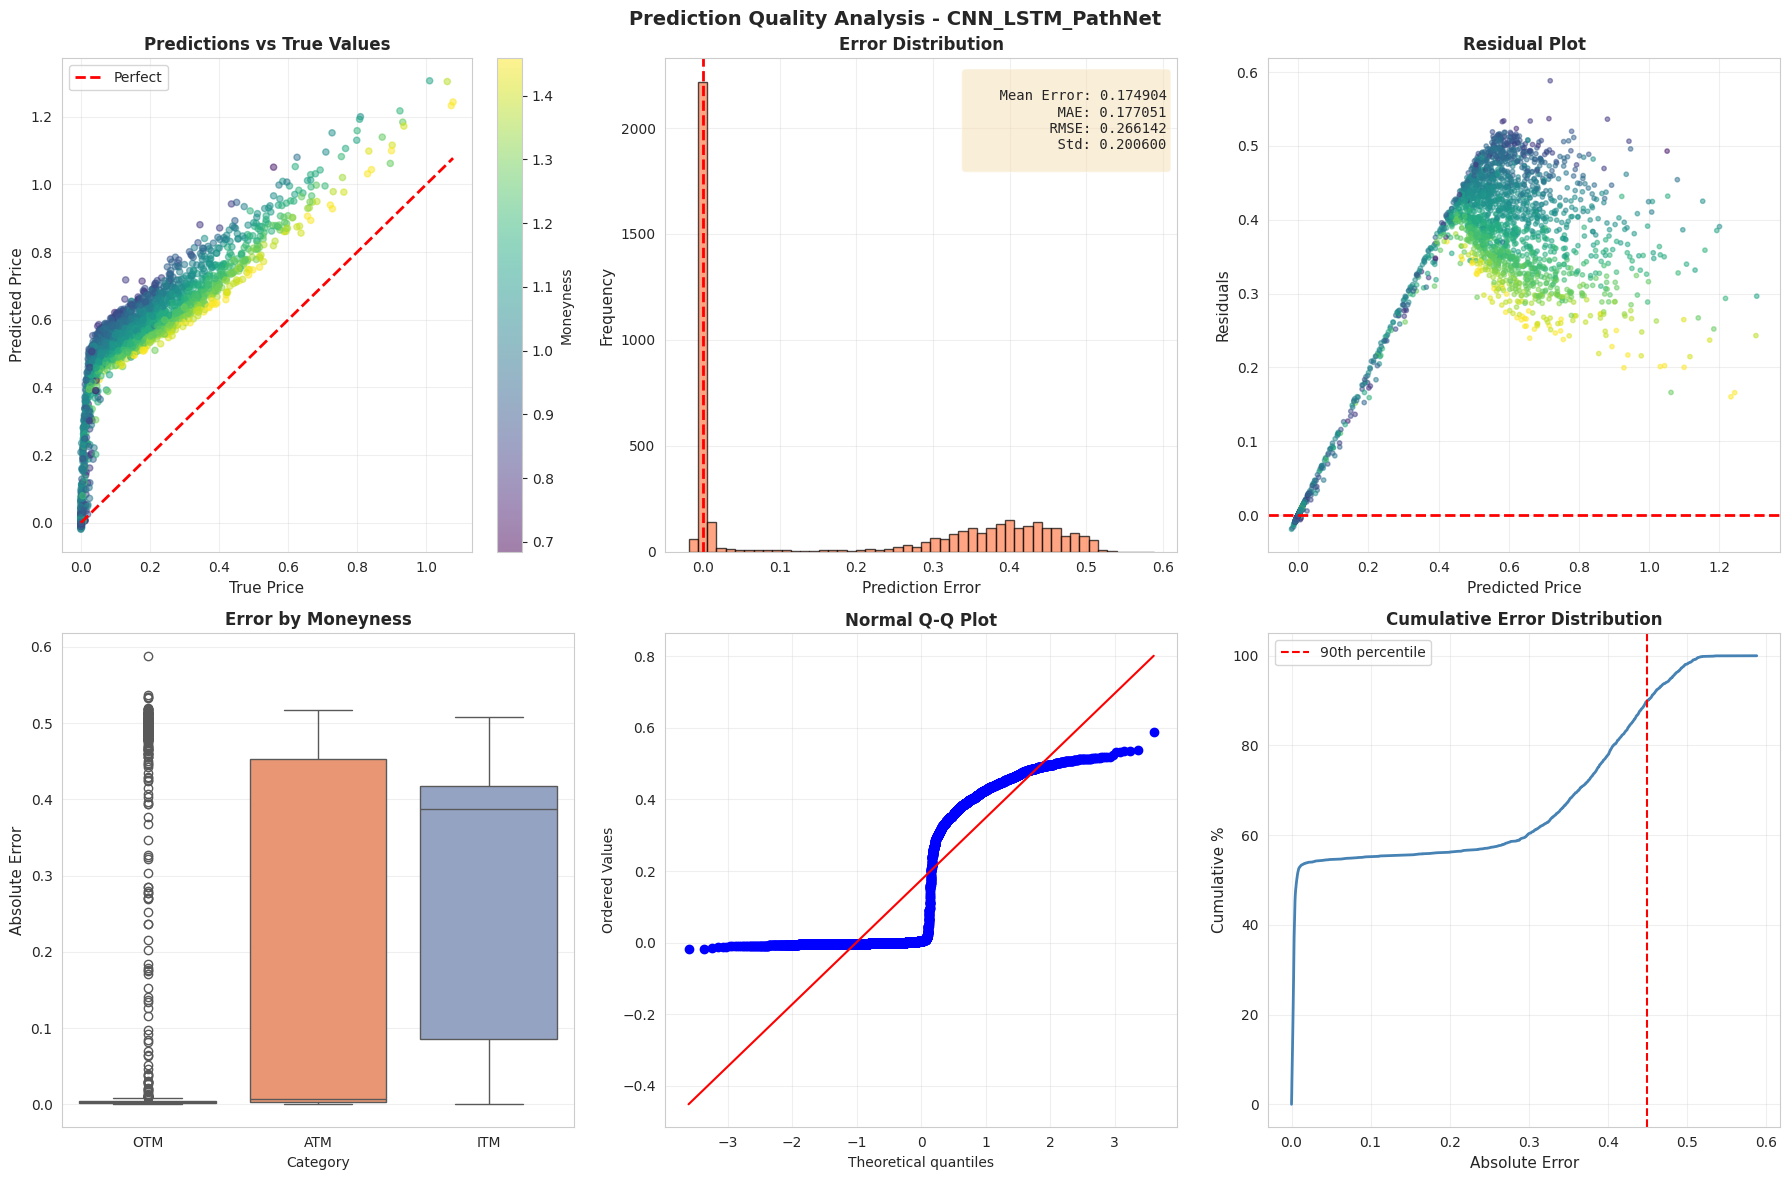


Prediction Quality Statistics:
MAE:  0.177051
RMSE: 0.266142
Max Error: 0.588333
90th Percentile: 0.450070


/tmp/ipython-input-3226865556.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Error', data=error_df, ax=ax, palette='Set2')


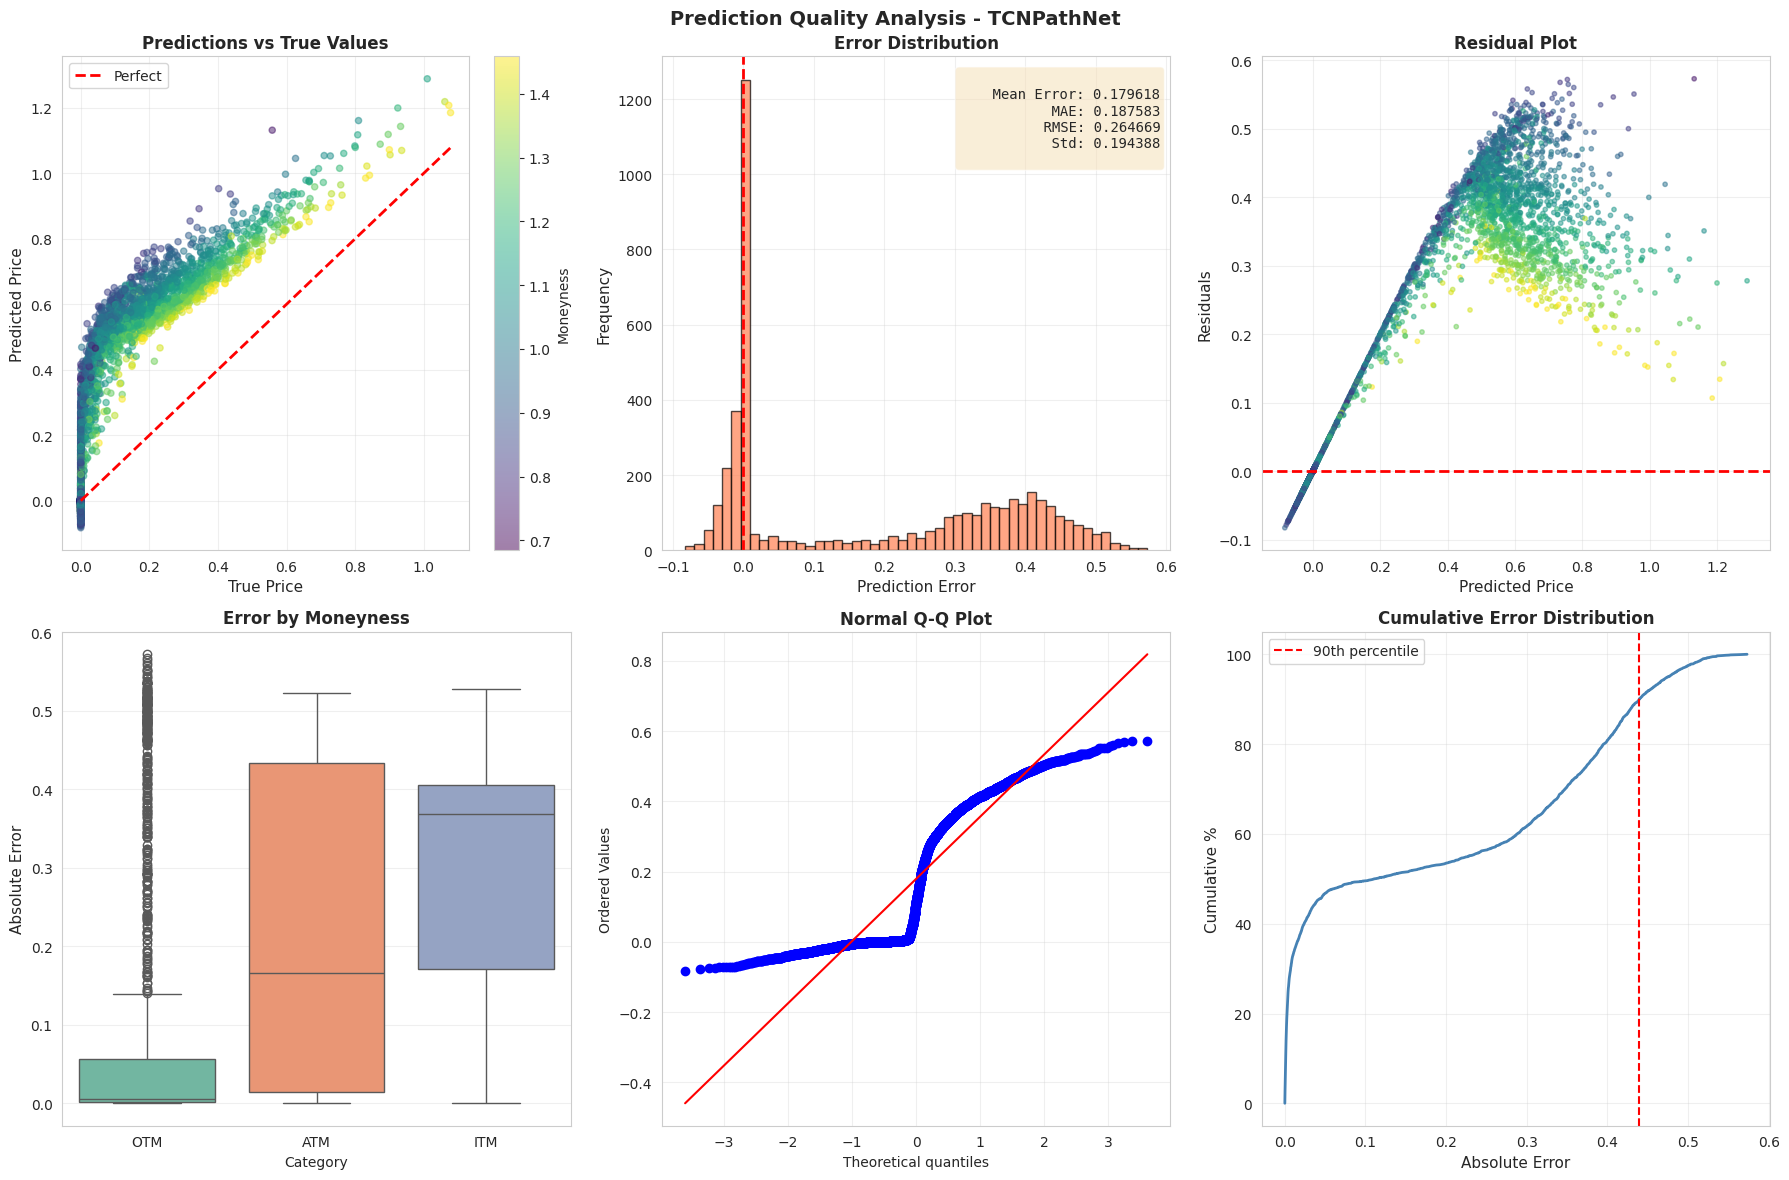


Prediction Quality Statistics:
MAE:  0.187583
RMSE: 0.264669
Max Error: 0.573159
90th Percentile: 0.439540

✓ All Enhancements Complete!


In [ ]:
# ============================================
# ENHANCEMENT 4: prediction qualitility analysis
# ============================================

print("\n" + "="*70)
print("Section 5.8: Prediction Quality Analysis")
print("="*70)

def analyze_prediction_quality(model, test_loader, X_test):
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for x, y in test_loader:
            preds = model(x.to(device))
            all_preds.append(preds.cpu().numpy())
            all_targets.append(y.numpy())

    preds = np.concatenate(all_preds)[:, 0]
    targets = np.concatenate(all_targets)[:, 0]
    errors = preds - targets

    # moneyness
    k_over_s0 = X_test[:len(preds), -1]
    moneyness = 1 / k_over_s0

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # 1. preiction vs actual
    ax = axes[0, 0]
    scatter = ax.scatter(targets, preds, c=moneyness, cmap='viridis',
                        alpha=0.5, s=20)
    ax.plot([targets.min(), targets.max()],
           [targets.min(), targets.max()],
           'r--', lw=2, label='Perfect')
    ax.set_xlabel('True Price', fontsize=11)
    ax.set_ylabel('Predicted Price', fontsize=11)
    ax.set_title('Predictions vs True Values', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax, label='Moneyness')

    # 2. distribution of errors
    ax = axes[0, 1]
    ax.hist(errors, bins=50, alpha=0.7, color='coral', edgecolor='black')
    ax.axvline(0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('Prediction Error', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title('Error Distribution', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

    text = f"""
    Mean Error: {errors.mean():.6f}
    MAE: {np.abs(errors).mean():.6f}
    RMSE: {np.sqrt((errors**2).mean()):.6f}
    Std: {errors.std():.6f}
    """
    ax.text(0.98, 0.97, text, transform=ax.transAxes,
           fontsize=10, verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
           family='monospace')

    # 3. errors vs predictions
    ax = axes[0, 2]
    ax.scatter(preds, errors, alpha=0.5, s=10, c=moneyness, cmap='viridis')
    ax.axhline(0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('Predicted Price', fontsize=11)
    ax.set_ylabel('Residuals', fontsize=11)
    ax.set_title('Residual Plot', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # 4. errors grouped by moneyness
    ax = axes[1, 0]
    bins = [0.8, 0.95, 1.05, 1.2]
    labels = ['OTM', 'ATM', 'ITM']
    moneyness_cat = pd.cut(moneyness, bins=bins, labels=labels)
    error_df = pd.DataFrame({'Category': moneyness_cat, 'Error': np.abs(errors)})
    sns.boxplot(x='Category', y='Error', data=error_df, ax=ax, palette='Set2')
    ax.set_ylabel('Absolute Error', fontsize=11)
    ax.set_title('Error by Moneyness', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # 5. QQ plot
    ax = axes[1, 1]
    stats.probplot(errors, dist="norm", plot=ax)
    ax.set_title('Normal Q-Q Plot', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # 6. distribution of cumulative distribution
    ax = axes[1, 2]
    sorted_abs_errors = np.sort(np.abs(errors))
    cumulative = np.arange(1, len(sorted_abs_errors) + 1) / len(sorted_abs_errors)
    ax.plot(sorted_abs_errors, cumulative * 100, linewidth=2, color='steelblue')
    ax.axvline(np.percentile(np.abs(errors), 90), color='red',
              linestyle='--', label='90th percentile')
    ax.set_xlabel('Absolute Error', fontsize=11)
    ax.set_ylabel('Cumulative %', fontsize=11)
    ax.set_title('Cumulative Error Distribution', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.suptitle(f'Prediction Quality Analysis - {model.__class__.__name__}',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\nPrediction Quality Statistics:")
    print("="*50)
    print(f"MAE:  {np.abs(errors).mean():.6f}")
    print(f"RMSE: {np.sqrt((errors**2).mean()):.6f}")
    print(f"Max Error: {np.abs(errors).max():.6f}")
    print(f"90th Percentile: {np.percentile(np.abs(errors), 90):.6f}")
    print("="*50)

analyze_prediction_quality(cnn_model, test_loader, X_test)
analyze_prediction_quality(lstm_model, test_loader, X_test)
analyze_prediction_quality(cnn_lstm_model, test_loader, X_test)
analyze_prediction_quality(tcn_model, test_loader, X_test)


print("\n" + "="*70)
print("✓ All Enhancements Complete!")
print("="*70)


## Section 5.6 – Training and Validation Loss Visualization  

This section visualizes the **training and validation loss curves** for each model  
(MLP, CNN, and LSTM). These plots help assess convergence behavior  
and detect potential overfitting or underfitting during training.

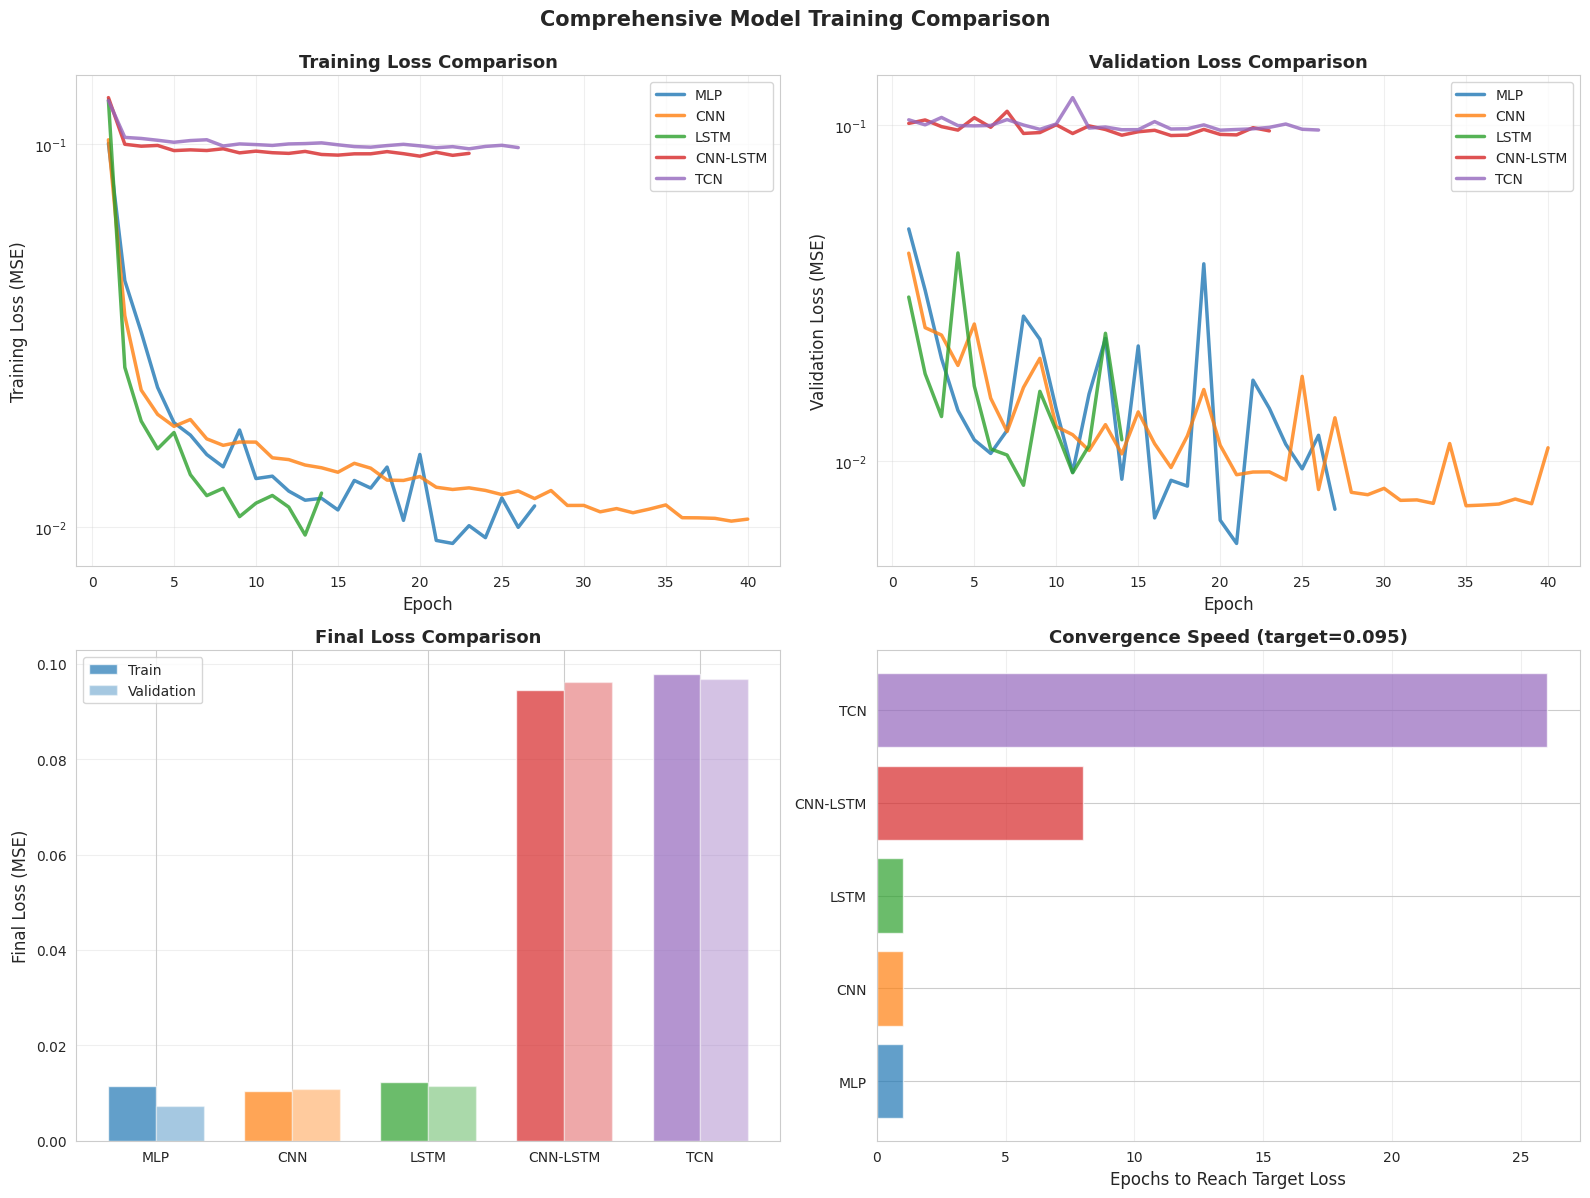

In [ ]:
# comparison of all models
def plot_all_models_comparison(histories, model_names):

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    # 1. traning loss
    ax = axes[0, 0]
    for history, name, color in zip(histories, model_names, colors):
        epochs = range(1, len(history['train_loss']) + 1)
        ax.plot(epochs, history['train_loss'], '-',
               label=name, linewidth=2.5, color=color, alpha=0.8)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Training Loss (MSE)', fontsize=12)
    ax.set_title('Training Loss Comparison', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

    # 2. validation loss
    ax = axes[0, 1]
    for history, name, color in zip(histories, model_names, colors):
        epochs = range(1, len(history['val_loss']) + 1)
        ax.plot(epochs, history['val_loss'], '-',
               label=name, linewidth=2.5, color=color, alpha=0.8)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Validation Loss (MSE)', fontsize=12)
    ax.set_title('Validation Loss Comparison', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

    # 3. histogram of final loss
    ax = axes[1, 0]
    final_train = [h['train_loss'][-1] for h in histories]
    final_val = [h['val_loss'][-1] for h in histories]
    x = np.arange(len(model_names))
    width = 0.35

    ax.bar(x - width/2, final_train, width, label='Train',
           color=colors, alpha=0.7)
    ax.bar(x + width/2, final_val, width, label='Validation',
           color=colors, alpha=0.4)
    ax.set_ylabel('Final Loss (MSE)', fontsize=12)
    ax.set_title('Final Loss Comparison', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    # 4. speed of convergence（number of epoches before reaching at objective loss）
    ax = axes[1, 1]
    target_loss = 0.095
    epochs_to_target = []
    for history in histories:
        val_losses = history['val_loss']
        try:
            epoch = next(i for i, loss in enumerate(val_losses) if loss < target_loss)
            epochs_to_target.append(epoch + 1)
        except StopIteration:
            epochs_to_target.append(len(val_losses))

    ax.barh(model_names, epochs_to_target, color=colors, alpha=0.7)
    ax.set_xlabel('Epochs to Reach Target Loss', fontsize=12)
    ax.set_title(f'Convergence Speed (target={target_loss})',
                fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')

    plt.suptitle('Comprehensive Model Training Comparison',
                fontsize=15, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

histories = [mlp_history, cnn_history, lstm_history, cnn_lstm_history, tcn_history]
model_names = ['MLP', 'CNN', 'LSTM', 'CNN-LSTM', 'TCN']
plot_all_models_comparison(histories, model_names)

# Section 6 – Benchmarking Neural Network Pricing Accuracy  

In this section, we compare the performance of neural network–based pricers  
against traditional high-precision Monte Carlo (MC) simulations.  
The MC method serves as the ground-truth benchmark to evaluate  
pricing accuracy, efficiency, and robustness across parameter regimes.

## Section 6.1 – High-Precision Monte Carlo Baseline  

We begin by implementing a **high-precision Monte Carlo (MC)** pricer  
for the arithmetic Asian call option.  
This pricer, using tens of thousands of simulated paths, provides  
a reliable reference value for assessing neural network approximation errors.  
Each call returns both the estimated price and the computation time.

In [ ]:

# ============================================
# Section 6.1: High-path Monte Carlo baseline (price only)
# ============================================

import time
import numpy as np

def price_asian_mc_high_precision(S0, K, r, q, sigma, T,
                                  n_steps=50,
                                  n_paths=50000,
                                  seed=123):
    """
    High-precision Monte Carlo pricing for an arithmetic Asian call.
    This is treated as our 'ground truth' baseline for price.

    The underlying GBM path generator is implemented manually using
    NumPy (log-Euler scheme), not QuantLib, to avoid environment
    compatibility issues.

    Args:
        S0, K, r, q, sigma, T: model and option parameters
        n_steps: number of time steps per path
        n_paths: number of Monte Carlo paths (large)
        seed: random seed

    Returns:
        price: estimated option price
        runtime: time in seconds
    """
    start = time.time()

    # --- Simulate GBM paths (NumPy implementation) ---
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    Z = rng.standard_normal(size=(n_paths, n_steps))
    drift = (r - q - 0.5 * sigma**2) * dt
    diffusion = sigma * np.sqrt(dt) * Z
    log_returns = drift + diffusion

    paths = np.zeros((n_paths, n_steps + 1), dtype=np.float32)
    paths[:, 0] = S0
    for t in range(n_steps):
        paths[:, t + 1] = paths[:, t] * np.exp(log_returns[:, t])

    # --- Discounted arithmetic Asian payoff ---
    payoff = asian_discounted_payoff(paths, K, r, T)
    price = float(payoff.mean())

    end = time.time()
    return price, end - start


## Section 6.2 – Neural Network–Based Few-Path Pricing  

In this part, we implement a **neural network (NN)–assisted pricer** that replaces the  
Monte Carlo averaging with a trained neural network.  
Instead of simulating tens of thousands of paths, only a few hundred paths are sampled,  
and their normalized trajectories are passed through the trained NN to predict  
the discounted payoff.  

The resulting price is rescaled by \( K \) to match currency units.  
This approach aims to achieve comparable pricing accuracy with **significantly reduced computation time**.

In [ ]:
# ============================================
# Section 6.2: Few-path pricing using a trained NN (price only)
# ============================================

def price_asian_with_nn(model, S0, K, r, q, sigma, T,
                        n_steps=50,
                        n_paths=200,
                        seed=456):
    """
    Price an Asian option using few Monte Carlo paths and a trained
    multi-task NN. We only use the first head (price/K) here.

    Steps:
        1) Simulate n_paths GBM paths (NumPy).
        2) Normalize each path by K.
        3) Append K/S0 as an extra feature (same as in training).
        4) Feed into the trained model and take the price head.
        5) Average over paths and rescale by K.

    Returns:
        price: NN-enhanced price estimate
        runtime: time in seconds (simulation + NN inference)
    """
    import time
    import torch
    model.eval()
    start = time.time()

    # --- Step 1: Simulate GBM paths (NumPy implementation) ---
    paths = generate_gbm_paths_quantlib(S0, r, q, sigma, T, n_steps, n_paths, seed)

    # --- Step 2: Normalize by strike K (same as training) ---
    paths_scaled = paths / K                                  # (n_paths, n_steps+1)

    # --- Step 3: Append K/S0 as extra feature ---
    k_over_s0 = K / S0
    extra_feature = np.full(
        (paths_scaled.shape[0], 1),
        k_over_s0,
        dtype=np.float32
    )

    x_extended = np.concatenate(
        [paths_scaled.astype(np.float32), extra_feature],
        axis=1
    )                                                         # (n_paths, seq_len_ext)

    # --- Step 4: NN inference ---
    with torch.no_grad():
        x = torch.from_numpy(x_extended).float().to(device)
        preds = model(x)                                      # (n_paths, 2)
        price_head = preds[:, 0]                              # payoff/K
        avg_payoff_over_paths = price_head.mean().item()      # scalar

    # --- Step 5: Rescale to currency units ---
    price = avg_payoff_over_paths * K

    end = time.time()
    return price, end - start

## Section 6.3 – Single-Scenario Comparison: MC vs NN  

This experiment compares the **Monte Carlo (MC)** and **neural network (NN)** pricers  
under a single set of option parameters.  
Both methods use identical inputs, but differ in computational strategy:  
- **MC baseline** relies on a large number of simulated paths for convergence.  
- **NN-based pricer** uses only a few paths and leverages the trained model for payoff prediction.  

The function reports:  
- Monte Carlo and NN prices with respective runtimes,  
- absolute and relative errors (scaled by \( K \)), and  
- the achieved computational **speed-up** (\( \text{MC time} / \text{NN time} \)).  
This comparison highlights the trade-off between accuracy and efficiency.

In [ ]:
# ============================================
# Section 6.3: Single-scenario comparison of MC vs NN (price only)
# ============================================

def compare_mc_vs_nn(model, S0, K, r, q, sigma, T,
                     n_steps=50,
                     n_paths_mc=50000,
                     n_paths_nn=200):
    """
    Compare high-path Monte Carlo (MC) pricing with the few-path
    NN-enhanced pricing for one option setup.

    Prints:
        - MC price and runtime
        - NN price and runtime
        - absolute error
        - relative error (|Δ| / K)
        - speed-up factor
    """

    import time
    import torch

    def price_asian_with_nn_local(model, S0, K, r, q, sigma, T,
                                  n_steps=50, n_paths=200, seed=456):
        """Inline helper (formerly Section 6.2)."""
        model.eval()
        start = time.time()

        paths = generate_gbm_paths_quantlib(S0, r, q, sigma, T, n_steps, n_paths, seed)
        paths_scaled = paths / K
        k_over_s0 = K / S0
        extra_feature = np.full((paths_scaled.shape[0], 1), k_over_s0, dtype=np.float32)
        x_extended = np.concatenate([paths_scaled.astype(np.float32), extra_feature], axis=1)

        with torch.no_grad():
            x = torch.from_numpy(x_extended).float().to(device)
            preds = model(x)
            price_head = preds[:, 0]
            avg_payoff_over_paths = price_head.mean().item()

        price = avg_payoff_over_paths * K
        end = time.time()
        return price, end - start

    print("=== Parameter set ===")
    print(f"S0={S0:.2f}, K={K:.2f}, r={r:.3f}, q={q:.3f}, "
          f"sigma={sigma:.3f}, T={T:.2f}")
    print(f"n_steps = {n_steps}, MC paths = {n_paths_mc}, NN paths = {n_paths_nn}")

    # --- Monte Carlo baseline ---
    mc_price, mc_time = price_asian_mc_high_precision(S0, K, r, q, sigma, T,
                                                      n_steps=n_steps,
                                                      n_paths=n_paths_mc)

    # --- NN-based pricing ---
    nn_price, nn_time = price_asian_with_nn_local(model, S0, K, r, q, sigma, T,
                                                  n_steps=n_steps,
                                                  n_paths=n_paths_nn)

    # --- Metrics ---
    abs_error = abs(nn_price - mc_price)
    rel_error_K = abs_error / K if K != 0 else float("nan")
    speedup = mc_time / nn_time if nn_time > 0 else float("inf")

    print("\n--- Results (Price only) ---")
    print(f"MC price (high-path): {mc_price:.6f}, time = {mc_time:.4f} s")
    print(f"NN price (few-path ): {nn_price:.6f}, time = {nn_time:.4f} s")
    print(f"Absolute error      : {abs_error:.6f}")
    print(f"Rel error (|Δ|/K)   : {rel_error_K*100:.4f}%")
    print(f"Speed-up (MC / NN)  : {speedup:.2f}x")


# --- Example scenario (near at-the-money, medium maturity) ---
S0_example = 100.0
K_example  = 100.0
r_example  = 0.01
q_example  = 0.00
sigma_example = 0.2
T_example  = 1.0

# Compare using the CNN (usually performs best)
compare_mc_vs_nn(
    model=cnn_model,
    S0=S0_example,
    K=K_example,
    r=r_example,
    q=q_example,
    sigma=sigma_example,
    T=T_example,
    n_steps=50,
    n_paths_mc=50000,   # high-precision MC
    n_paths_nn=200      # few paths for NN
)

=== Parameter set ===
S0=100.00, K=100.00, r=0.010, q=0.000, sigma=0.200, T=1.00
n_steps = 50, MC paths = 50000, NN paths = 200

--- Results (Price only) ---
MC price (high-path): 4.822351, time = 0.2823 s
NN price (few-path ): 6.394569, time = 0.0148 s
Absolute error      : 1.572217
Rel error (|Δ|/K)   : 1.5722%
Speed-up (MC / NN)  : 19.09x


## Section 6.4 – Evaluation of NN Pricer over Random Parameter Sets

In this section, we quantitatively compare the CNN and LSTM neural-network pricers against the high-path Monte Carlo baseline.  
For each randomly sampled parameter set within the same training regime, both methods are evaluated on:
- **MAE** – mean absolute price error,  
- **Relative Error (|Δ| / K)** – average relative error percentage,  
- **Speed-up** – ratio of Monte Carlo runtime to NN runtime.

This analysis demonstrates the overall pricing accuracy and computational efficiency of the trained models.

In [ ]:
# Section 6.4: Evaluate NN pricer over random parameter sets (price only)

def evaluate_nn_over_random_params(model,
                                   n_cases=50,
                                   n_steps=50,
                                   n_paths_mc=50000,
                                   n_paths_nn=200,
                                   seed=999):
    """
    Sample multiple parameter sets from the SAME 'regular' regime used
    for training, and compare MC vs NN pricing for each.

    Metrics:
        - MAE: mean absolute price error
        - RelErr_K: mean relative error |Δ|/K (as percentage)
        - avg_speedup: average (MC_time / NN_time)
    """
    # Use the same sampler as in Section 2 (consistency with training distribution)
    S0_arr, K_arr, sigma_arr, r_arr, q_arr, T_arr = sample_regular_params(
        n_cases, seed=seed
    )

    abs_errors = []
    rel_errors_K = []
    speedups = []

    for i in range(n_cases):
        S0 = S0_arr[i]
        K  = K_arr[i]
        sigma = sigma_arr[i]
        r = r_arr[i]
        q = q_arr[i]
        T = T_arr[i]

        # High-path MC baseline
        mc_price, mc_time = price_asian_mc_high_precision(
            S0, K, r, q, sigma, T,
            n_steps=n_steps,
            n_paths=n_paths_mc
        )

        # Few-path NN surrogate
        nn_price, nn_time = price_asian_with_nn(
            model, S0, K, r, q, sigma, T,
            n_steps=n_steps,
            n_paths=n_paths_nn
        )

        abs_err = abs(nn_price - mc_price)
        rel_err_K = abs_err / K if K != 0 else float("nan")
        speedup = mc_time / nn_time if nn_time > 0 else float("inf")

        abs_errors.append(abs_err)
        rel_errors_K.append(rel_err_K)
        speedups.append(speedup)

    summary = {
        "MAE": float(np.mean(abs_errors)),
        "RelErr_K": float(np.mean(rel_errors_K)) * 100.0,  # percentage
        "avg_speedup": float(np.mean(speedups))
    }
    return summary


In [ ]:
summary_cnn = evaluate_nn_over_random_params(
    cnn_model,
    n_cases=30,
    n_steps=50,
    n_paths_mc=30000,
    n_paths_nn=200,
    seed=2025
)

print("\n===== CNN NN-pricer summary over random cases =====")
print(f"MAE (abs price error)   : {summary_cnn['MAE']:.6f}")
print(f"Rel error (|Δ|/K)       : {summary_cnn['RelErr_K']:.4f}%")
print(f"Speed-up (MC/NN, avg)   : {summary_cnn['avg_speedup']:.2f}x")



===== CNN NN-pricer summary over random cases =====
MAE (abs price error)   : 1.558490
Rel error (|Δ|/K)       : 1.5029%
Speed-up (MC/NN, avg)   : 14.99x


In [ ]:
summary_lstm = evaluate_nn_over_random_params(
    lstm_model,
    n_cases=30,
    n_steps=50,
    n_paths_mc=30000,
    n_paths_nn=200,
    seed=2026
)

print("\n===== LSTM NN-pricer summary over random cases =====")
print(f"MAE (abs price error)   : {summary_lstm['MAE']:.6f}")
print(f"Rel error (|Δ|/K)       : {summary_lstm['RelErr_K']:.4f}%")
print(f"Speed-up (MC/NN, avg)   : {summary_lstm['avg_speedup']:.2f}x")




===== LSTM NN-pricer summary over random cases =====
MAE (abs price error)   : 0.771244
Rel error (|Δ|/K)       : 0.8096%
Speed-up (MC/NN, avg)   : 4.51x


In [ ]:
def print_summary(name, summary):
    print(f"\n===== {name} NN-pricer summary over random cases =====")
    print(f"MAE (abs price error)   : {summary['MAE']:.6f}")
    print(f"Rel error (|Δ|/K)       : {summary['RelErr_K']:.4f}%")
    print(f"Speed-up (MC/NN, avg)   : {summary['avg_speedup']:.2f}x")

print_summary("CNN", summary_cnn)
print_summary("LSTM", summary_lstm)



===== CNN NN-pricer summary over random cases =====
MAE (abs price error)   : 1.558490
Rel error (|Δ|/K)       : 1.5029%
Speed-up (MC/NN, avg)   : 14.99x

===== LSTM NN-pricer summary over random cases =====
MAE (abs price error)   : 0.771244
Rel error (|Δ|/K)       : 0.8096%
Speed-up (MC/NN, avg)   : 4.51x


## Section 6.5 – Monte Carlo Estimation of Price and Delta

After validating neural-network pricing accuracy, this section extends the benchmark  
to include **Delta estimation** — the sensitivity of the Asian option price to the initial  
spot price \( S_0 \). The Monte Carlo results here serve as the ground truth for evaluating  
the neural-network Delta predictions.

### Section 6.5.1 – High-Path Monte Carlo Estimation of Price and Delta

In [ ]:
# Section 6.5.1: High-path Monte Carlo for both price and Delta

def price_asian_mc_with_delta(S0, K, r, q, sigma, T,
                              n_steps=50,
                              n_paths=50000,
                              seed=123):
    """
    High-precision Monte Carlo for both price and Delta
    of an arithmetic Asian call under GBM.

    Uses the pathwise derivative formula:
        Delta_path = exp(-rT) * 1_{A > K} * (A / S0)
    where A is the arithmetic average of the path.

    Returns:
        mc_price : scalar
        mc_delta : scalar
        runtime  : time in seconds
    """
    start = time.time()

    paths = simulate_gbm_paths(S0, r, q, sigma, T, n_steps, n_paths)

    # Price
    payoff = asian_discounted_payoff(paths, K, r, T)       # (n_paths,)

    # Pathwise Delta
    A = paths.mean(axis=1)                                 # (n_paths,)
    indicator = (A > K).astype(np.float32)
    dA_dS0 = A / S0
    delta_path = np.exp(-r * T) * indicator * dA_dS0       # (n_paths,)

    mc_price = float(payoff.mean())
    mc_delta = float(delta_path.mean())

    end = time.time()
    return mc_price, mc_delta, end - start


### Section 6.5.2 – Neural Network Estimation of Price and Delta

In [ ]:
# Section 6.5.2: NN-based price and Delta from multi-task model

def price_asian_with_nn_price_and_delta(model, S0, K, r, q, sigma, T,
                                        n_steps=50,
                                        n_paths=200,
                                        seed=456):
    """
    Use the multi-task NN to estimate both price and Delta.
    The model outputs [price/K, delta] per path.
    """
    model.eval()
    start = time.time()

    paths = simulate_gbm_paths(S0, r, q, sigma, T, n_steps, n_paths)
    paths_scaled = paths / K

    k_over_s0 = K / S0
    extra_feature = np.full(
        (paths_scaled.shape[0], 1),
        k_over_s0,
        dtype=np.float32
    )
    x_extended = np.concatenate(
        [paths_scaled.astype(np.float32), extra_feature],
        axis=1
    )

    import torch
    with torch.no_grad():
        x = torch.from_numpy(x_extended).float().to(device)
        preds = model(x)                                    # (n_paths, 2)
        price_head = preds[:, 0]                            # payoff/K
        delta_head = preds[:, 1]                            # Delta

        avg_price_over_paths = price_head.mean().item()
        avg_delta_over_paths = delta_head.mean().item()

    nn_price = avg_price_over_paths * K
    nn_delta = avg_delta_over_paths

    end = time.time()
    return nn_price, nn_delta, end - start


### Section 6.5.3 – Comparison of Monte Carlo and Neural Network for Price and Delta


In [ ]:
# ============================================
# Section 6.5.3: Compare MC vs NN for both price and Delta
# ============================================

def simulate_gbm_paths(S0, r, q, sigma, T, n_steps, n_paths, seed=42):
    """
    Generate GBM price paths using NumPy under Black–Scholes dynamics:
        dS = (r - q)Sdt + sigma S dW
    Discretization:
        S_{t+1} = S_t * exp[(r - q - 0.5*sigma^2)*dt + sigma*sqrt(dt)*Z_t]
    """
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    Z = rng.standard_normal(size=(n_paths, n_steps))
    drift = (r - q - 0.5 * sigma**2) * dt
    diffusion = sigma * np.sqrt(dt) * Z

    paths = np.zeros((n_paths, n_steps + 1), dtype=np.float32)
    paths[:, 0] = S0
    for t in range(n_steps):
        paths[:, t + 1] = paths[:, t] * np.exp(drift + diffusion[:, t])
    return paths


def compare_mc_vs_nn_with_delta(model, S0, K, r, q, sigma, T,
                                n_steps=50,
                                n_paths_mc=50000,
                                n_paths_nn=200):
    """
    Compare high-path MC vs. few-path+NN for both price and Delta.
    """
    print("=== Parameter set (Price & Delta) ===")
    print(f"S0={S0:.2f}, K={K:.2f}, r={r:.3f}, q={q:.3f}, "
          f"sigma={sigma:.3f}, T={T:.2f}")
    print(f"n_steps = {n_steps}, MC paths = {n_paths_mc}, NN paths = {n_paths_nn}")

    mc_price, mc_delta, mc_time = price_asian_mc_with_delta(
        S0, K, r, q, sigma, T,
        n_steps=n_steps,
        n_paths=n_paths_mc
    )

    nn_price, nn_delta, nn_time = price_asian_with_nn_price_and_delta(
        model, S0, K, r, q, sigma, T,
        n_steps=n_steps,
        n_paths=n_paths_nn
    )

    # Errors
    price_abs_err = abs(nn_price - mc_price)
    price_rel_err_K = price_abs_err / K if K != 0 else float("nan")

    delta_abs_err = abs(nn_delta - mc_delta)
    delta_rel_err = delta_abs_err / abs(mc_delta) if mc_delta != 0 else float("nan")

    speedup = mc_time / nn_time if nn_time > 0 else float("inf")

    print("\n--- Results (Price & Delta) ---")
    print(f"MC price  : {mc_price:.6f},   time = {mc_time:.4f} s")
    print(f"NN price  : {nn_price:.6f},   time = {nn_time:.4f} s")
    print(f"Price abs error      : {price_abs_err:.6f}")
    print(f"Price rel (|Δ|/K)    : {price_rel_err_K*100:.4f}%")
    print(f"\nMC Delta  : {mc_delta:.6f}")
    print(f"NN Delta  : {nn_delta:.6f}")
    print(f"Delta abs error      : {delta_abs_err:.6f}")
    print(f"Delta rel vs MC      : {delta_rel_err*100:.4f}%")
    print(f"\nSpeed-up (MC / NN)   : {speedup:.2f}x")


# ---------- Example Scenarios ----------

# Case 1: ATM, moderate vol, 1Y
compare_mc_vs_nn_with_delta(
    model=cnn_model,
    S0=100, K=100, r=0.01, q=0.00,
    sigma=0.20, T=1.0,
    n_steps=50,
    n_paths_mc=50000,
    n_paths_nn=200
)

# Case 2: ITM, higher vol, longer maturity
compare_mc_vs_nn_with_delta(
    model=cnn_model,
    S0=120, K=100, r=0.02, q=0.00,
    sigma=0.30, T=2.0,
    n_steps=50,
    n_paths_mc=50000,
    n_paths_nn=200
)

# Case 3: LSTM model, moderate vol
compare_mc_vs_nn_with_delta(
    model=lstm_model,
    S0=100, K=100, r=0.01, q=0.00,
    sigma=0.20, T=1.0,
    n_steps=50,
    n_paths_mc=50000,
    n_paths_nn=200
)

# Case 4: LSTM model, OTM, high vol
compare_mc_vs_nn_with_delta(
    model=lstm_model,
    S0=90, K=110, r=0.015, q=0.00,
    sigma=0.35, T=1.5,
    n_steps=50,
    n_paths_mc=50000,
    n_paths_nn=200
)

=== Parameter set (Price & Delta) ===
S0=100.00, K=100.00, r=0.010, q=0.000, sigma=0.200, T=1.00
n_steps = 50, MC paths = 50000, NN paths = 200

--- Results (Price & Delta) ---
MC price  : 4.810709,   time = 0.2261 s
NN price  : 5.706995,   time = 0.0113 s
Price abs error      : 0.896287
Price rel (|Δ|/K)    : 0.8963%

MC Delta  : 0.534637
NN Delta  : 0.556034
Delta abs error      : 0.021397
Delta rel vs MC      : 4.0021%

Speed-up (MC / NN)   : 20.05x
=== Parameter set (Price & Delta) ===
S0=120.00, K=100.00, r=0.020, q=0.000, sigma=0.300, T=2.00
n_steps = 50, MC paths = 50000, NN paths = 200

--- Results (Price & Delta) ---
MC price  : 24.398138,   time = 0.2178 s
NN price  : 24.918847,   time = 0.0111 s
Price abs error      : 0.520709
Price rel (|Δ|/K)    : 0.5207%

MC Delta  : 0.811930
NN Delta  : 0.862841
Delta abs error      : 0.050911
Delta rel vs MC      : 6.2703%

Speed-up (MC / NN)   : 19.59x
=== Parameter set (Price & Delta) ===
S0=100.00, K=100.00, r=0.010, q=0.000, sigma=0

## Section 7: Pricing Curve

Computing MC curve (ground truth)...


100%|██████████| 41/41 [00:08<00:00,  4.75it/s]



Computing CNN curve...

Computing LSTM curve...

Computing CNN-LSTM curve...

Computing TCN curve...


/tmp/ipython-input-3211440711.py:193: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_speedup.set_xticklabels(model_names, rotation=45, ha='right')


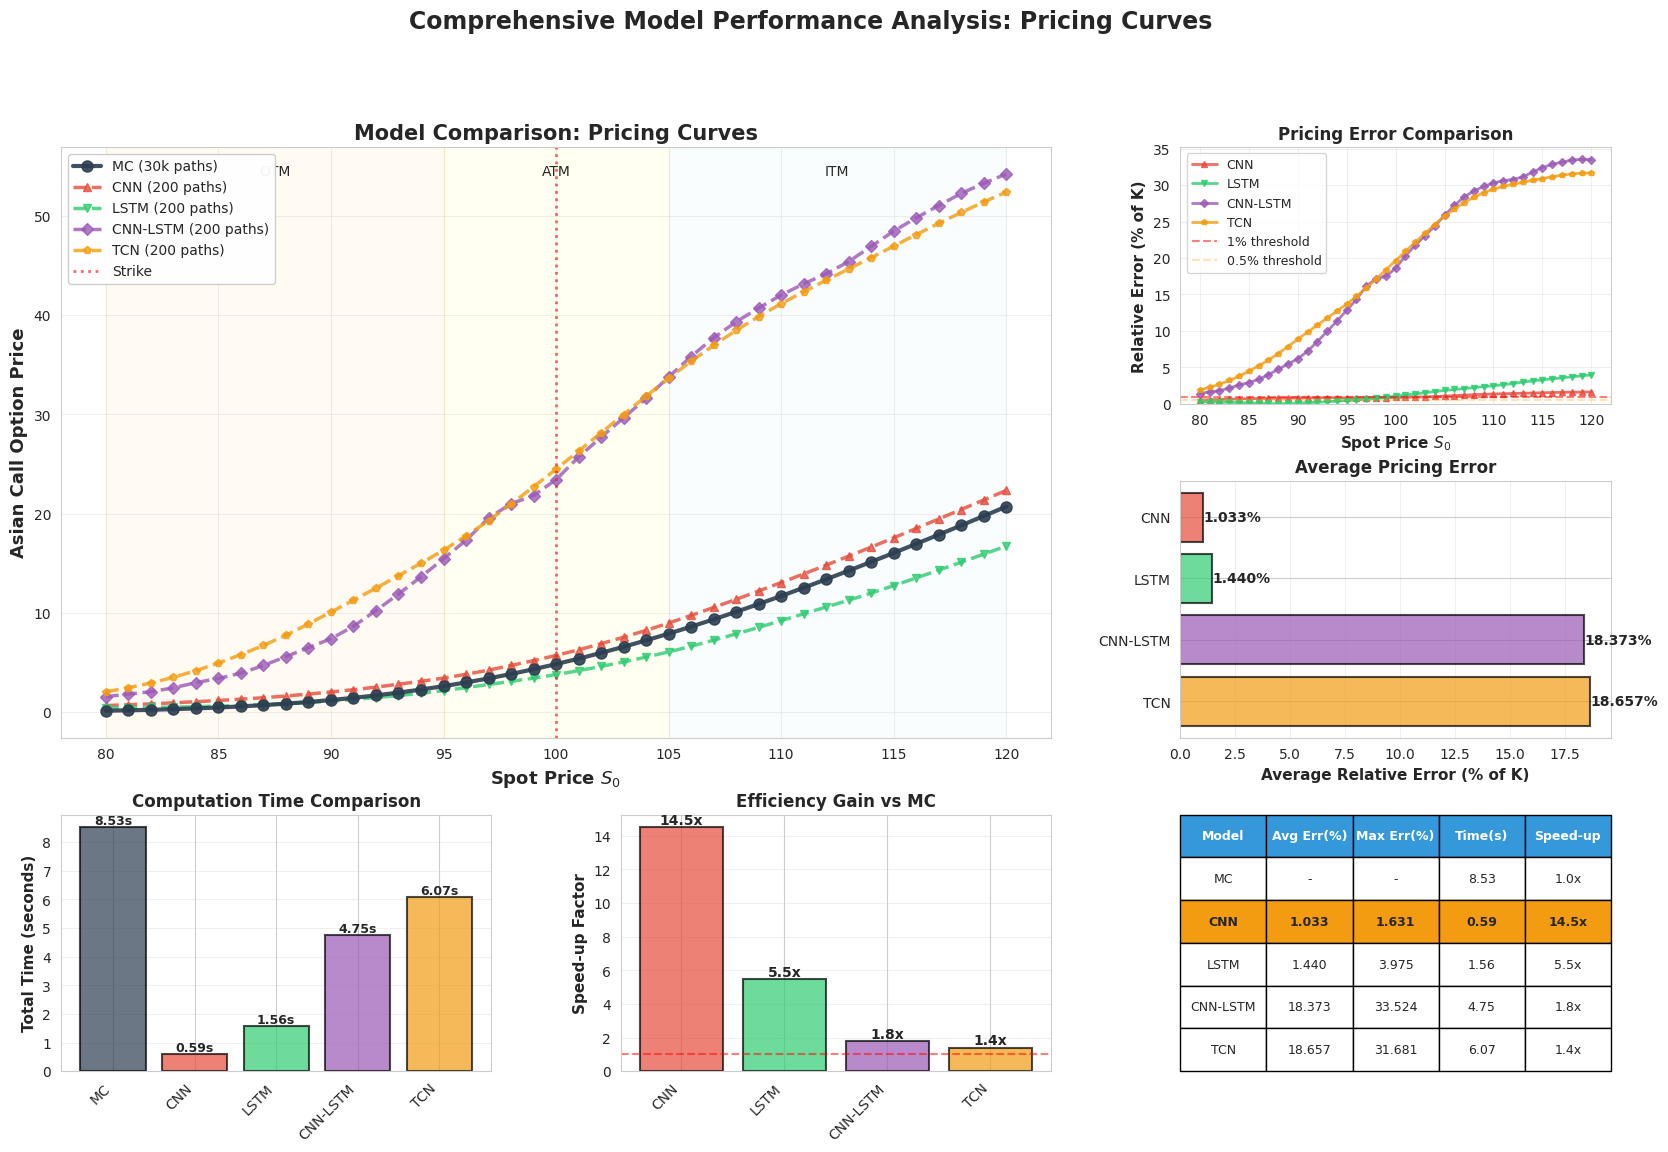


COMPREHENSIVE MODEL COMPARISON SUMMARY

Configuration: K=100, σ=0.2, r=0.01, q=0.0, T=1.0
Evaluation points: 41 (S0 ∈ [80, 120])

--------------------------------------------------------------------------------
Model        Avg Err(%)   Max Err(%)   Time(s)    Speed-up  
--------------------------------------------------------------------------------
MC           -            -            8.53       1.0x      
CNN          1.0332       1.6311       0.59       14.5      x
LSTM         1.4404       3.9755       1.56       5.5       x
CNN-LSTM     18.3726      33.5239      4.75       1.8       x
TCN          18.6575      31.6813      6.07       1.4       x
--------------------------------------------------------------------------------

🏆 Best Model: CNN
   Average Error: 1.0332%
   Speed-up: 14.5x


In [ ]:
def compare_all_models_pricing_curve(models_dict, K=100, sigma=0.2, r=0.01, q=0.0, T=1.0):
    S0_range = np.linspace(80, 120, 41)

    mc_prices = []
    all_nn_prices = {}
    all_times = {}

    # ===== MC prices =====
    print("Computing MC curve (ground truth)...")
    mc_times = []
    for S0 in tqdm(S0_range):
        start = time.time()
        price, _ = price_asian_mc_high_precision(S0, K, r, q, sigma, T, 50, 30000)
        mc_prices.append(price)
        mc_times.append(time.time() - start)

    mc_prices = np.array(mc_prices)

    # ===== NN prices =====
    for model_name, model in models_dict.items():
        print(f"\nComputing {model_name} curve...")
        start = time.time()

        all_X = []
        for S0 in S0_range:
            paths = generate_gbm_paths_quantlib(S0, r, q, sigma, T, 50, 200, seed=42)
            paths_scaled = paths / K
            extra = np.full((200, 1), K/S0, dtype=np.float32)
            X = np.concatenate([paths_scaled.astype(np.float32), extra], axis=1)
            all_X.append(X)

        all_X = np.concatenate(all_X, axis=0)
        with torch.no_grad():
            x = torch.from_numpy(all_X).float().to(device)
            preds = model(x)[:, 0].cpu().numpy()

        nn_prices = [preds[i*200:(i+1)*200].mean() * K for i in range(len(S0_range))]
        nn_time = time.time() - start

        all_nn_prices[model_name] = np.array(nn_prices)
        all_times[model_name] = nn_time

    # ===== 3. visulization =====
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    colors = {
        'MC': '#2c3e50',
        'CNN': '#e74c3c',
        'LSTM': '#2ecc71',
        'CNN-LSTM': '#9b59b6',
        'TCN': '#f39c12'
    }
    markers = {
        'MC': 'o',
        'CNN': '^',
        'LSTM': 'v',
        'CNN-LSTM': 'D',
        'TCN': 'p'
    }

    # === pricing curve comparison ===
    ax_main = fig.add_subplot(gs[0:2, 0:2])

    # MC baseline
    ax_main.plot(S0_range, mc_prices, marker='o', linestyle='-',
                label='MC (30k paths)', linewidth=3, markersize=8,
                color=colors['MC'], alpha=0.9, zorder=10)

    # all NN models
    for model_name, nn_prices in all_nn_prices.items():
        ax_main.plot(S0_range, nn_prices,
                    marker=markers.get(model_name, 's'),
                    linestyle='--',
                    label=f'{model_name} (200 paths)',
                    linewidth=2.5, markersize=6,
                    color=colors.get(model_name, 'gray'),
                    alpha=0.8)

    ax_main.axvline(K, color='red', linestyle=':', alpha=0.6, linewidth=2, label='Strike')
    ax_main.axvspan(80, 95, alpha=0.05, color='orange')
    ax_main.text(87.5, ax_main.get_ylim()[1]*0.95, 'OTM', fontsize=10, ha='center')
    ax_main.axvspan(95, 105, alpha=0.05, color='yellow')
    ax_main.text(100, ax_main.get_ylim()[1]*0.95, 'ATM', fontsize=10, ha='center')
    ax_main.axvspan(105, 120, alpha=0.05, color='lightblue')
    ax_main.text(112.5, ax_main.get_ylim()[1]*0.95, 'ITM', fontsize=10, ha='center')

    ax_main.set_xlabel('Spot Price $S_0$', fontsize=13, fontweight='bold')
    ax_main.set_ylabel('Asian Call Option Price', fontsize=13, fontweight='bold')
    ax_main.set_title('Model Comparison: Pricing Curves', fontsize=15, fontweight='bold')
    ax_main.legend(fontsize=10, loc='upper left', framealpha=0.95)
    ax_main.grid(True, alpha=0.3)

    # === relative errors (in comparison with strike)===
    ax_error = fig.add_subplot(gs[0, 2])

    for model_name, nn_prices in all_nn_prices.items():
        abs_errors = np.abs(nn_prices - mc_prices)
        rel_errors_K = abs_errors / K * 100

        ax_error.plot(S0_range, rel_errors_K,
                     marker=markers.get(model_name, 's'),
                     linestyle='-',
                     label=model_name,
                     linewidth=2, markersize=4,
                     color=colors.get(model_name, 'gray'),
                     alpha=0.8)

    ax_error.axhline(1.0, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='1% threshold')
    ax_error.axhline(0.5, color='orange', linestyle='--', alpha=0.3, linewidth=1.5, label='0.5% threshold')
    ax_error.set_xlabel('Spot Price $S_0$', fontsize=11, fontweight='bold')
    ax_error.set_ylabel('Relative Error (% of K)', fontsize=11, fontweight='bold')
    ax_error.set_title('Pricing Error Comparison', fontsize=12, fontweight='bold')
    ax_error.legend(fontsize=9)
    ax_error.grid(True, alpha=0.3)
    ax_error.set_ylim([0, max(2, ax_error.get_ylim()[1])])

    # === average error histogram ===
    ax_bar = fig.add_subplot(gs[1, 2])

    model_names = list(all_nn_prices.keys())
    avg_errors = []

    for model_name in model_names:
        nn_prices = all_nn_prices[model_name]
        abs_errors = np.abs(nn_prices - mc_prices)
        rel_errors_K = abs_errors / K * 100
        avg_errors.append(rel_errors_K.mean())

    bars = ax_bar.barh(model_names, avg_errors,
                       color=[colors.get(name, 'gray') for name in model_names],
                       alpha=0.7, edgecolor='black', linewidth=1.5)

    for bar, err in zip(bars, avg_errors):
        width = bar.get_width()
        ax_bar.text(width, bar.get_y() + bar.get_height()/2.,
                   f'{err:.3f}%',
                   ha='left', va='center', fontsize=10, fontweight='bold')

    ax_bar.set_xlabel('Average Relative Error (% of K)', fontsize=11, fontweight='bold')
    ax_bar.set_title('Average Pricing Error', fontsize=12, fontweight='bold')
    ax_bar.grid(True, alpha=0.3, axis='x')
    ax_bar.invert_yaxis()

    # === computation time ===
    ax_time = fig.add_subplot(gs[2, 0])

    times_list = [sum(mc_times)] + [all_times[name] for name in model_names]
    labels_list = ['MC'] + model_names
    colors_list = [colors['MC']] + [colors.get(name, 'gray') for name in model_names]

    bars = ax_time.bar(range(len(labels_list)), times_list,
                      color=colors_list, alpha=0.7, edgecolor='black', linewidth=1.5)

    ax_time.set_xticks(range(len(labels_list)))
    ax_time.set_xticklabels(labels_list, rotation=45, ha='right')
    ax_time.set_ylabel('Total Time (seconds)', fontsize=11, fontweight='bold')
    ax_time.set_title('Computation Time Comparison', fontsize=12, fontweight='bold')
    ax_time.grid(True, alpha=0.3, axis='y')

    for bar, t in zip(bars, times_list):
        height = bar.get_height()
        ax_time.text(bar.get_x() + bar.get_width()/2., height,
                    f'{t:.2f}s',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

    # === speed up ratio ===
    ax_speedup = fig.add_subplot(gs[2, 1])

    speedups = [sum(mc_times) / all_times[name] for name in model_names]

    bars = ax_speedup.bar(model_names, speedups,
                         color=[colors.get(name, 'gray') for name in model_names],
                         alpha=0.7, edgecolor='black', linewidth=1.5)

    ax_speedup.set_ylabel('Speed-up Factor', fontsize=11, fontweight='bold')
    ax_speedup.set_title('Efficiency Gain vs MC', fontsize=12, fontweight='bold')
    ax_speedup.set_xticklabels(model_names, rotation=45, ha='right')
    ax_speedup.grid(True, alpha=0.3, axis='y')
    ax_speedup.axhline(1, color='red', linestyle='--', alpha=0.5, linewidth=1.5)

    for bar, sp in zip(bars, speedups):
        height = bar.get_height()
        ax_speedup.text(bar.get_x() + bar.get_width()/2., height,
                       f'{sp:.1f}x',
                       ha='center', va='bottom', fontsize=10, fontweight='bold')

    # === summary ===
    ax_table = fig.add_subplot(gs[2, 2])
    ax_table.axis('off')

    table_data = [['Model', 'Avg Err(%)', 'Max Err(%)', 'Time(s)', 'Speed-up']]
    table_data.append(['MC', '-', '-', f'{sum(mc_times):.2f}', '1.0x'])

    for model_name in model_names:
        nn_prices = all_nn_prices[model_name]
        abs_errors = np.abs(nn_prices - mc_prices)
        rel_errors_K = abs_errors / K * 100

        avg_err = rel_errors_K.mean()
        max_err = rel_errors_K.max()
        time_val = all_times[model_name]
        speedup = sum(mc_times) / time_val

        table_data.append([
            model_name,
            f'{avg_err:.3f}',
            f'{max_err:.3f}',
            f'{time_val:.2f}',
            f'{speedup:.1f}x'
        ])

    table = ax_table.table(cellText=table_data, cellLoc='center',
                          loc='center', bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)

    for i in range(5):
        table[(0, i)].set_facecolor('#3498db')
        table[(0, i)].set_text_props(weight='bold', color='white')

    best_model_idx = avg_errors.index(min(avg_errors)) + 2  # +2因为有标题行和MC行
    for i in range(5):
        table[(best_model_idx, i)].set_facecolor('#f39c12')
        table[(best_model_idx, i)].set_text_props(weight='bold')

    plt.suptitle('Comprehensive Model Performance Analysis: Pricing Curves',
                fontsize=17, fontweight='bold', y=0.995)

    plt.savefig('pricing_curve_comparison_all_models.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n" + "="*80)
    print("COMPREHENSIVE MODEL COMPARISON SUMMARY")
    print("="*80)

    print(f"\nConfiguration: K={K}, σ={sigma}, r={r}, q={q}, T={T}")
    print(f"Evaluation points: {len(S0_range)} (S0 ∈ [{S0_range.min():.0f}, {S0_range.max():.0f}])")

    print("\n" + "-"*80)
    print(f"{'Model':<12} {'Avg Err(%)':<12} {'Max Err(%)':<12} {'Time(s)':<10} {'Speed-up':<10}")
    print("-"*80)
    print(f"{'MC':<12} {'-':<12} {'-':<12} {sum(mc_times):<10.2f} {'1.0x':<10}")

    for model_name in model_names:
        nn_prices = all_nn_prices[model_name]
        abs_errors = np.abs(nn_prices - mc_prices)
        rel_errors_K = abs_errors / K * 100

        avg_err = rel_errors_K.mean()
        max_err = rel_errors_K.max()
        time_val = all_times[model_name]
        speedup = sum(mc_times) / time_val

        print(f"{model_name:<12} {avg_err:<12.4f} {max_err:<12.4f} {time_val:<10.2f} {speedup:<10.1f}x")

    print("-"*80)

    best_model = min(model_names, key=lambda name:
                    (np.abs(all_nn_prices[name] - mc_prices) / K * 100).mean())
    print(f"\n🏆 Best Model: {best_model}")
    print(f"   Average Error: {(np.abs(all_nn_prices[best_model] - mc_prices) / K * 100).mean():.4f}%")
    print(f"   Speed-up: {sum(mc_times) / all_times[best_model]:.1f}x")

    print("="*80)

    return mc_prices, all_nn_prices, all_times

models = {
    'CNN': cnn_model,
    'LSTM': lstm_model,
    'CNN-LSTM': cnn_lstm_model,
    'TCN': tcn_model
}

mc_prices, all_nn_prices, all_times = compare_all_models_pricing_curve(
    models_dict=models,
    K=100,
    sigma=0.2,
    r=0.01,
    q=0.0,
    T=1.0
)



Computing MC curve (41 points)...


100%|██████████| 41/41 [00:06<00:00,  6.77it/s]


Computing NN curve...


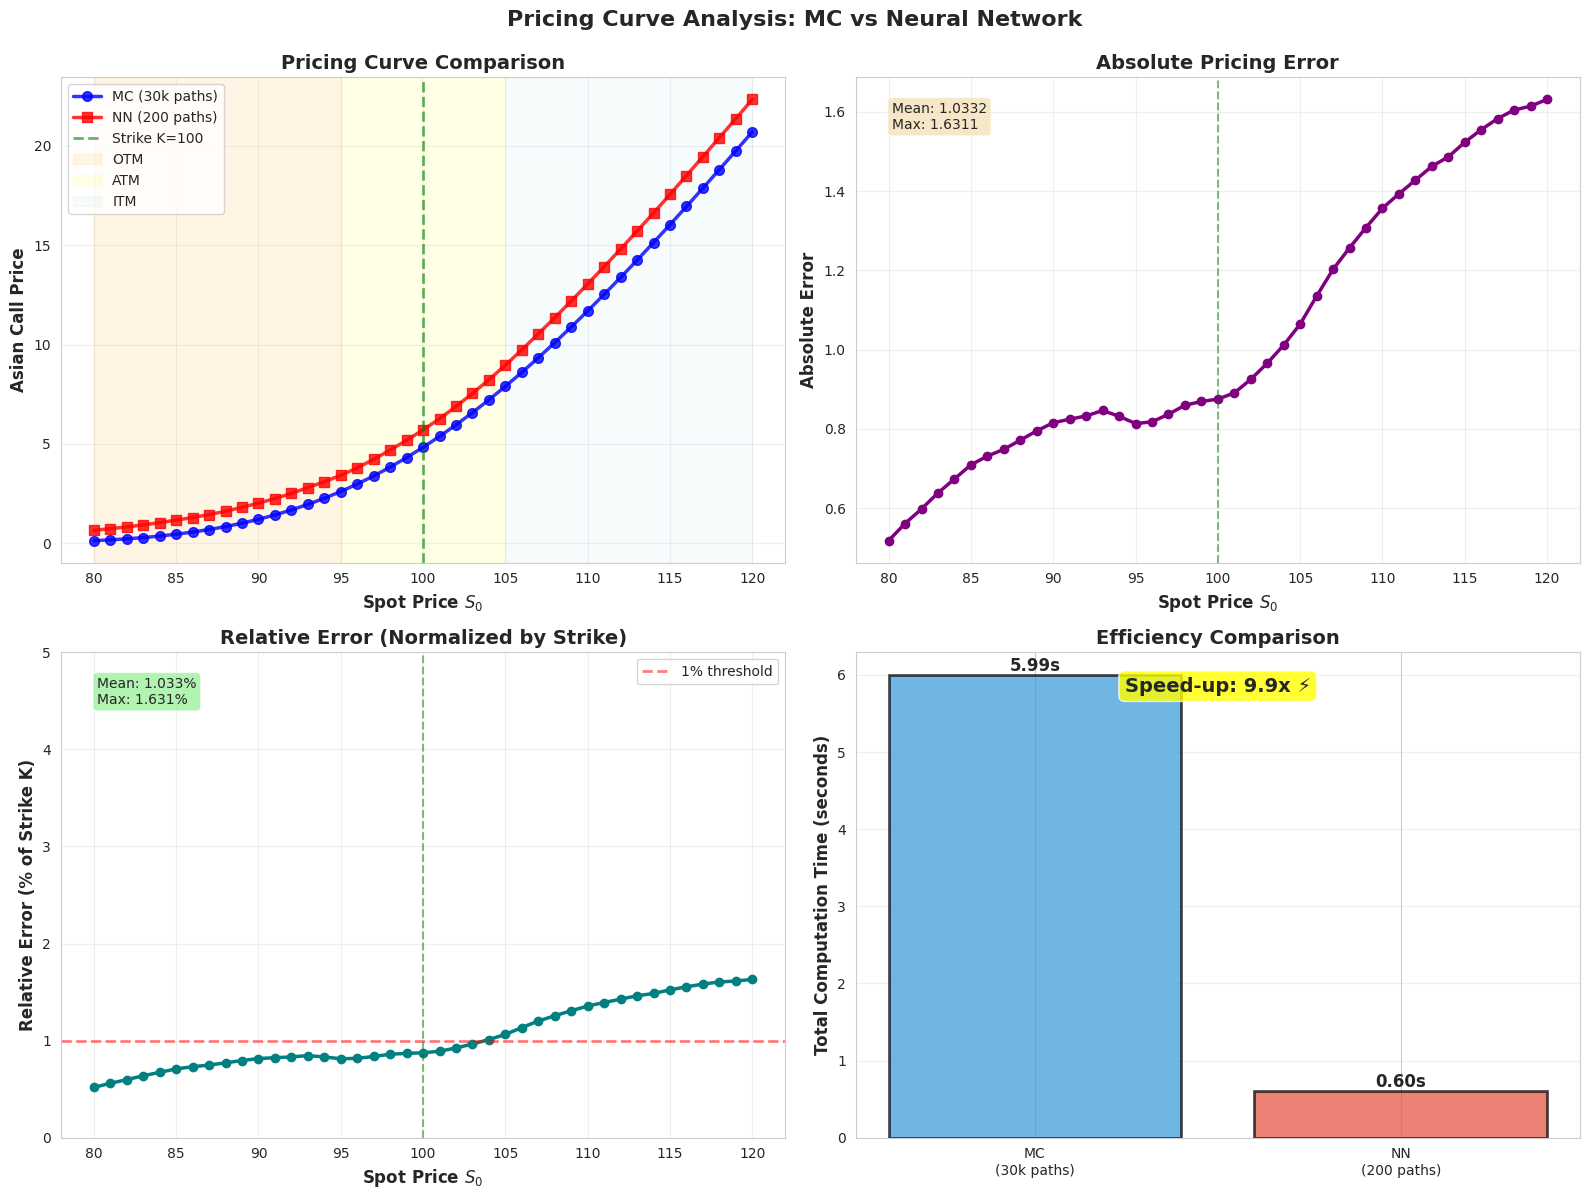


PRICING CURVE SUMMARY

 Configuration:
   Points evaluated: 41
   Strike K: 100
   Volatility σ: 0.2
   S0 range: [80, 120]

 Computation Time:
   MC total:  5.99s (0.146s per point)
   NN total:  0.60s (0.015s per point)
   Speed-up:  9.9x ⚡

 Error Metrics (Absolute):
   Mean abs error:  1.0332
   Median abs err:  0.8751
   Max abs error:   1.6311
   Std abs error:   0.3351

 Error Metrics (Relative to Strike K=100):
   Mean rel error:  1.033%
   Median rel err:  0.875%
   Max rel error:   1.631%

 Error by Moneyness Region:
   OTM (S0<95):   0.726% avg
   ATM (95≤S0≤105): 0.903% avg
   ITM (S0>105):  1.436% avg

 Quality Assessment:
   Points with <1% error:  24/41 (58.5%)
   Points with <2% error:  41/41 (100.0%)

Processing σ=0.15...


σ=0.15: 100%|██████████| 21/21 [00:01<00:00, 13.53it/s]



Processing σ=0.25...


σ=0.25: 100%|██████████| 21/21 [00:01<00:00, 10.53it/s]



Processing σ=0.35...


σ=0.35: 100%|██████████| 21/21 [00:01<00:00, 11.37it/s]


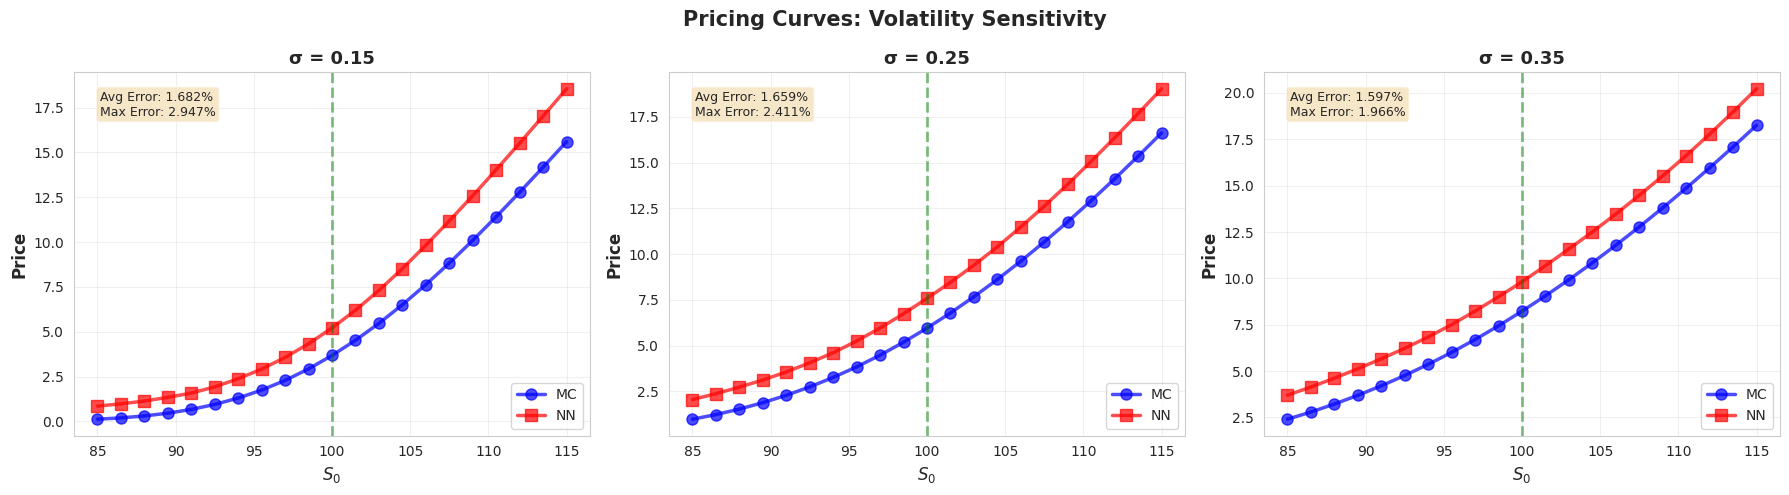

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import time
from tqdm import tqdm

def plot_pricing_curve_fixed(model, K=100, sigma=0.2, r=0.01, q=0.0, T=1.0):
    S0_range = np.linspace(80, 120, 41)
    mc_prices, nn_prices = [], []
    mc_times, nn_times = [], []

    # MC
    print("Computing MC curve (41 points)...")
    for S0 in tqdm(S0_range):
        start = time.time()
        price, _ = price_asian_mc_high_precision(S0, K, r, q, sigma, T, 50, 30000)
        mc_prices.append(price)
        mc_times.append(time.time() - start)

    # NN
    print("Computing NN curve...")
    start = time.time()
    all_X = []
    for S0 in S0_range:
        paths = generate_gbm_paths_quantlib(S0, r, q, sigma, T, 50, 200, seed=42)
        paths_scaled = paths / K
        extra = np.full((200, 1), K/S0, dtype=np.float32)
        X = np.concatenate([paths_scaled.astype(np.float32), extra], axis=1)
        all_X.append(X)

    all_X = np.concatenate(all_X, axis=0)
    with torch.no_grad():
        x = torch.from_numpy(all_X).float().to(device)
        preds = model(x)[:, 0].cpu().numpy()

    nn_prices = [preds[i*200:(i+1)*200].mean() * K for i in range(len(S0_range))]
    nn_total_time = time.time() - start

    # ===== errors computation (three ways)=====
    mc_prices = np.array(mc_prices)
    nn_prices = np.array(nn_prices)

    # absoulte error
    abs_errors = np.abs(nn_prices - mc_prices)

    # relative error (% of strike)
    rel_errors_K = abs_errors / K * 100

    # relative error (meaningful prices)
    # kick off OTM
    meaningful_mask = mc_prices > 0.1
    rel_errors_price = np.full_like(mc_prices, np.nan)
    rel_errors_price[meaningful_mask] = (abs_errors[meaningful_mask] /
                                         mc_prices[meaningful_mask] * 100)

    # ===== visulization =====
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. pricing curve comparison
    ax = axes[0, 0]
    ax.plot(S0_range, mc_prices, 'o-', label='MC (30k paths)',
            linewidth=2.5, markersize=7, color='blue', alpha=0.8)
    ax.plot(S0_range, nn_prices, 's-', label='NN (200 paths)',
            linewidth=2.5, markersize=7, color='red', alpha=0.8)
    ax.axvline(K, color='green', linestyle='--', alpha=0.6, linewidth=2,
              label=f'Strike K={K}')

    # mark ITM/ATM/OTM region
    ax.axvspan(80, 95, alpha=0.1, color='orange', label='OTM')
    ax.axvspan(95, 105, alpha=0.1, color='yellow', label='ATM')
    ax.axvspan(105, 120, alpha=0.1, color='lightblue', label='ITM')

    ax.set_xlabel('Spot Price $S_0$', fontsize=12, fontweight='bold')
    ax.set_ylabel('Asian Call Price', fontsize=12, fontweight='bold')
    ax.set_title('Pricing Curve Comparison', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10, loc='upper left')
    ax.grid(True, alpha=0.3)

    # 2. absolute error
    ax = axes[0, 1]
    ax.plot(S0_range, abs_errors, 'o-', color='purple', linewidth=2.5, markersize=6)
    ax.axvline(K, color='green', linestyle='--', alpha=0.5)
    ax.set_xlabel('Spot Price $S_0$', fontsize=12, fontweight='bold')
    ax.set_ylabel('Absolute Error', fontsize=12, fontweight='bold')
    ax.set_title('Absolute Pricing Error', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)


    text = f'Mean: {abs_errors.mean():.4f}\nMax: {abs_errors.max():.4f}'
    ax.text(0.05, 0.95, text, transform=ax.transAxes,
           fontsize=10, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

    # 3. relative error (% of strike)
    ax = axes[1, 0]
    ax.plot(S0_range, rel_errors_K, 'o-', color='teal', linewidth=2.5, markersize=6)
    ax.axhline(1.0, color='red', linestyle='--', alpha=0.5, linewidth=2,
              label='1% threshold')
    ax.axvline(K, color='green', linestyle='--', alpha=0.5)
    ax.set_xlabel('Spot Price $S_0$', fontsize=12, fontweight='bold')
    ax.set_ylabel('Relative Error (% of Strike K)', fontsize=12, fontweight='bold')
    ax.set_title('Relative Error (Normalized by Strike)', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, max(5, rel_errors_K.max() * 1.1)])

    text = f'Mean: {rel_errors_K.mean():.3f}%\nMax: {rel_errors_K.max():.3f}%'
    ax.text(0.05, 0.95, text, transform=ax.transAxes,
           fontsize=10, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

    # 4. computation curve
    ax = axes[1, 1]
    times = [sum(mc_times), nn_total_time]
    labels = ['MC\n(30k paths)', 'NN\n(200 paths)']
    colors_bar = ['#3498db', '#e74c3c']
    bars = ax.bar(labels, times, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=2)

    for bar, time_val in zip(bars, times):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{time_val:.2f}s',
               ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.set_ylabel('Total Computation Time (seconds)', fontsize=12, fontweight='bold')
    ax.set_title('Efficiency Comparison', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # speed up ratio
    speedup = sum(mc_times) / nn_total_time
    ax.text(0.5, 0.95, f'Speed-up: {speedup:.1f}x ⚡',
           transform=ax.transAxes, ha='center', va='top',
           fontsize=14, fontweight='bold',
           bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

    plt.suptitle('Pricing Curve Analysis: MC vs Neural Network',
                fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

    # ===== pricing curve summary =====
    print("\n" + "="*70)
    print("PRICING CURVE SUMMARY")
    print("="*70)
    print(f"\n Configuration:")
    print(f"   Points evaluated: {len(S0_range)}")
    print(f"   Strike K: {K}")
    print(f"   Volatility σ: {sigma}")
    print(f"   S0 range: [{S0_range.min():.0f}, {S0_range.max():.0f}]")

    print(f"\n Computation Time:")
    print(f"   MC total:  {sum(mc_times):.2f}s ({sum(mc_times)/len(S0_range):.3f}s per point)")
    print(f"   NN total:  {nn_total_time:.2f}s ({nn_total_time/len(S0_range):.3f}s per point)")
    print(f"   Speed-up:  {sum(mc_times)/nn_total_time:.1f}x ⚡")

    print(f"\n Error Metrics (Absolute):")
    print(f"   Mean abs error:  {abs_errors.mean():.4f}")
    print(f"   Median abs err:  {np.median(abs_errors):.4f}")
    print(f"   Max abs error:   {abs_errors.max():.4f}")
    print(f"   Std abs error:   {abs_errors.std():.4f}")

    print(f"\n Error Metrics (Relative to Strike K={K}):")
    print(f"   Mean rel error:  {rel_errors_K.mean():.3f}%")
    print(f"   Median rel err:  {np.median(rel_errors_K):.3f}%")
    print(f"   Max rel error:   {rel_errors_K.max():.3f}%")

    otm_mask = S0_range < 95
    atm_mask = (S0_range >= 95) & (S0_range <= 105)
    itm_mask = S0_range > 105

    print(f"\n Error by Moneyness Region:")
    print(f"   OTM (S0<95):   {rel_errors_K[otm_mask].mean():.3f}% avg")
    print(f"   ATM (95≤S0≤105): {rel_errors_K[atm_mask].mean():.3f}% avg")
    print(f"   ITM (S0>105):  {rel_errors_K[itm_mask].mean():.3f}% avg")

    print(f"\n Quality Assessment:")
    under_1pct = (rel_errors_K < 1.0).sum()
    under_2pct = (rel_errors_K < 2.0).sum()
    print(f"   Points with <1% error:  {under_1pct}/{len(S0_range)} ({under_1pct/len(S0_range)*100:.1f}%)")
    print(f"   Points with <2% error:  {under_2pct}/{len(S0_range)} ({under_2pct/len(S0_range)*100:.1f}%)")

    print("="*70)

    return mc_prices, nn_prices, abs_errors, rel_errors_K


# CNN
mc_prices, nn_prices, abs_errs, rel_errs = plot_pricing_curve_fixed(
    model=cnn_model,
    K=100,
    sigma=0.2,
    r=0.01,
    q=0.0,
    T=1.0
)

# ===== Different Volatilities =====

def compare_volatilities(model, sigmas=[0.15, 0.25, 0.35]):
    fig, axes = plt.subplots(1, len(sigmas), figsize=(6*len(sigmas), 5))

    if len(sigmas) == 1:
        axes = [axes]

    for idx, sigma in enumerate(sigmas):
        ax = axes[idx]

        S0_range = np.linspace(85, 115, 21)
        mc_p, nn_p = [], []

        print(f"\nProcessing σ={sigma}...")
        for S0 in tqdm(S0_range, desc=f"σ={sigma}"):
            # MC
            mc_price, _ = price_asian_mc_high_precision(
                S0, 100, 0.01, 0.0, sigma, 1.0, 50, 20000
            )
            # NN
            nn_price, _ = price_asian_with_nn(
                model, S0, 100, 0.01, 0.0, sigma, 1.0, 50, 200
            )
            mc_p.append(mc_price)
            nn_p.append(nn_price)

        ax.plot(S0_range, mc_p, 'o-', label='MC', linewidth=2.5,
               markersize=8, color='blue', alpha=0.7)
        ax.plot(S0_range, nn_p, 's-', label='NN', linewidth=2.5,
               markersize=8, color='red', alpha=0.7)
        ax.axvline(100, color='green', linestyle='--', alpha=0.5, linewidth=2)

        ax.set_xlabel('$S_0$', fontsize=12, fontweight='bold')
        ax.set_ylabel('Price', fontsize=12, fontweight='bold')
        ax.set_title(f'σ = {sigma}', fontsize=13, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)

        errors = np.abs(np.array(nn_p) - np.array(mc_p))
        rel_errors = errors / 100 * 100

        text = f'Avg Error: {rel_errors.mean():.3f}%\nMax Error: {rel_errors.max():.3f}%'
        ax.text(0.05, 0.95, text, transform=ax.transAxes,
               fontsize=9, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

    plt.suptitle('Pricing Curves: Volatility Sensitivity',
                fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

compare_volatilities(cnn_model, sigmas=[0.15, 0.25, 0.35])


# Extension A: Parameter Sensitivity and Error Analysis

## A.1 Purpose and Setup

This extension aims to analyze the CNN-based neural pricer’s generalization
behavior under varying market parameters.  
We evaluate model accuracy across a wide range of sampled parameter sets
and later visualize the sensitivity of errors with respect to
key variables such as moneyness ($S_0/K$), volatility ($\sigma$),
and maturity ($T$).

The evaluation function defined below generates paired Monte Carlo
and NN results for each sampled configuration, serving as the basis
for subsequent error landscape analysis.

In [ ]:
# ============================================
# Utility: Evaluate NN vs MC error by parameter
# ============================================

def evaluate_nn_error_by_params(model,
                                n_cases=200,
                                n_steps=50,
                                n_paths_mc=50000,
                                n_paths_nn=200,
                                seed=123):
    """
    Evaluate NN-based pricing errors versus high-precision Monte Carlo results
    across randomly sampled parameter combinations.

    Parameters
    ----------
    model : trained PyTorch model (e.g., cnn_model)
        Neural network pricer to evaluate.
    n_cases : int
        Number of random parameter sets.
    n_steps : int
        Number of time steps per simulated path.
    n_paths_mc : int
        Number of MC paths for high-precision baseline.
    n_paths_nn : int
        Number of MC paths for NN-based pricing.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    pandas.DataFrame
        Columns:
        ['S0', 'K', 'M', 'sigma', 'r', 'q', 'T',
         'MC_price', 'NN_price', 'abs_err', 'rel_err']
    """
    import pandas as pd
    records = []
    S0_arr, K_arr, sigma_arr, r_arr, q_arr, T_arr = sample_regular_params(
        n_cases, seed=seed
    )

    for i in tqdm(range(n_cases), desc="Evaluating NN vs MC pricing error"):
        S0, K, sigma, r, q, T = S0_arr[i], K_arr[i], sigma_arr[i], r_arr[i], q_arr[i], T_arr[i]

        # Monte Carlo reference (high-precision)
        mc_price, _ = price_asian_mc_high_precision(
            S0, K, r, q, sigma, T,
            n_steps=n_steps, n_paths=n_paths_mc, seed=seed + i
        )

        # NN approximation (fast)
        nn_price, _ = price_asian_with_nn(
            model, S0, K, r, q, sigma, T,
            n_steps=n_steps, n_paths=n_paths_nn, seed=seed + i
        )

        abs_err = abs(nn_price - mc_price)
        rel_err = abs_err / K
        records.append((S0, K, S0 / K, sigma, r, q, T,
                        mc_price, nn_price, abs_err, rel_err))

    df = pd.DataFrame(records, columns=[
        'S0', 'K', 'M', 'sigma', 'r', 'q', 'T',
        'MC_price', 'NN_price', 'abs_err', 'rel_err'
    ])
    return df

## A.2 Parameter Sensitivity and Error Visualization

We analyze how the CNN-based neural pricer’s performance varies across
the parameter space of the Asian option by comparing its outputs to
Monte Carlo benchmarks.  
For each sampled parameter combination $(S_0, K, \sigma, r, q, T)$,
we compute the following quantities:

$$
\text{abs err} = |\mathrm{NN} - \mathrm{MC}|, \quad
\text{rel err} = \frac{|\mathrm{NN} - \mathrm{MC}|}{K}, \quad
M = \frac{S_0}{K}
$$

Visualizations below show how the **relative error** depends on
moneyness ($M = S_0/K$), volatility ($\sigma$), and maturity ($T$),
revealing the regions where the neural model underperforms.

Evaluating NN vs MC: 100%|██████████| 200/200 [00:26<00:00,  7.58it/s]


Average relative error across parameter space: 0.394%


,M,sigma,T,rel_err
count,200.000000,200.000000,200.0,200.000000
mean,1.014650,0.250683,1.0,0.003942
std,0.163758,0.086656,0.0,0.003509
min,0.689133,0.100212,1.0,0.000021
25%,0.877914,0.179131,1.0,0.001375
50%,0.995985,0.247599,1.0,0.002768
75%,1.130119,0.326041,1.0,0.005166
max,1.441434,0.398380,1.0,0.015896


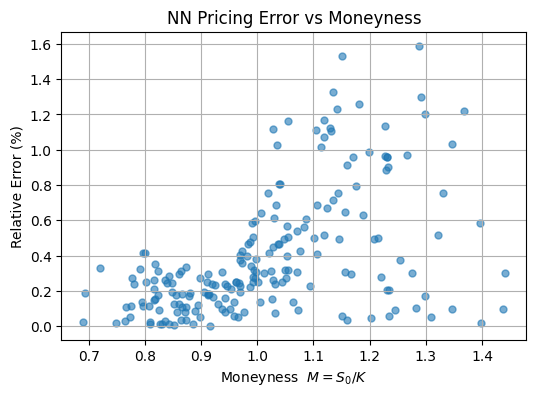

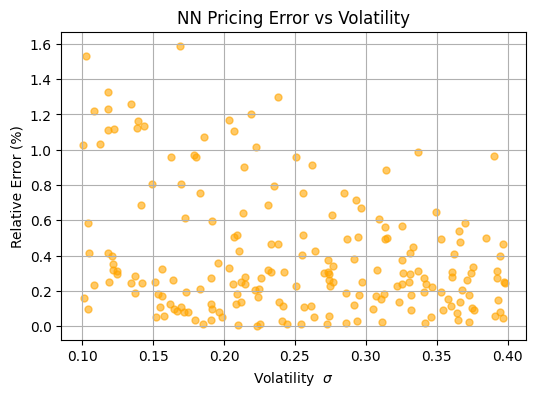

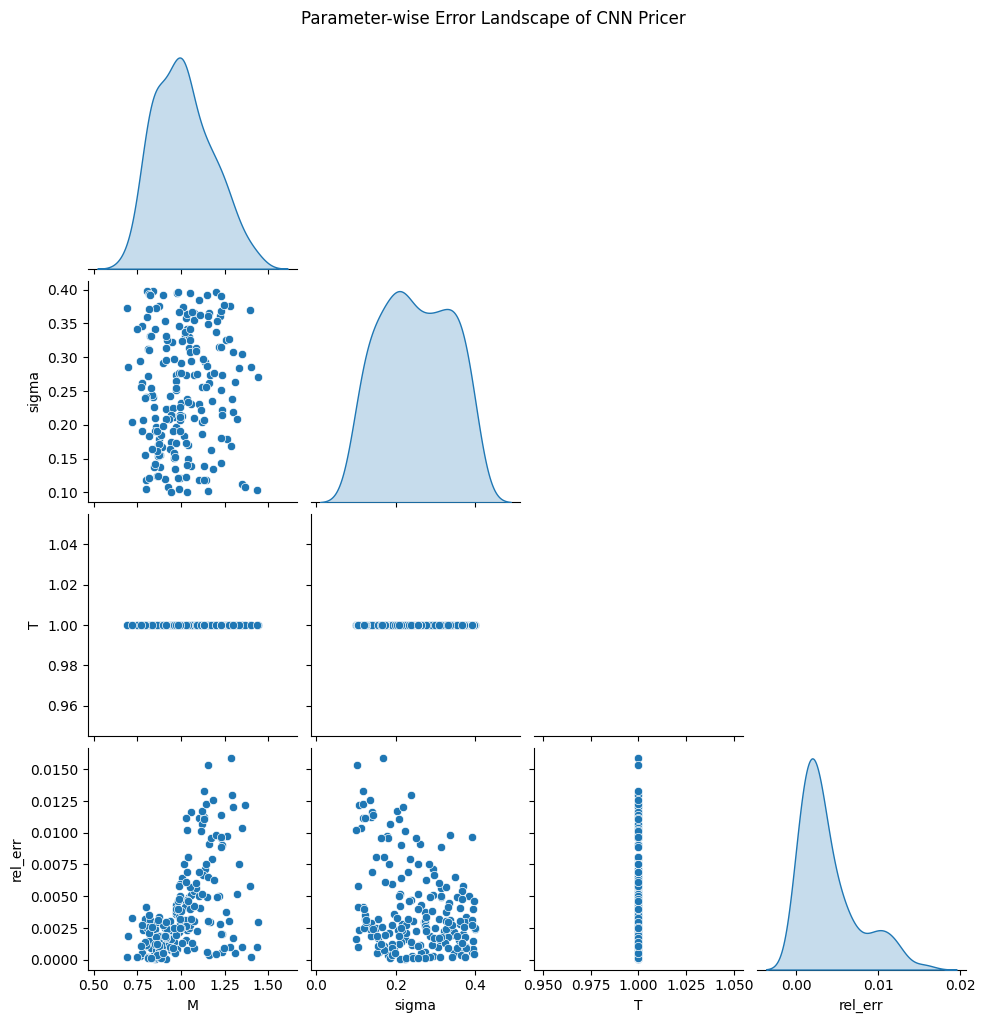

In [ ]:
# ============================================
# Extension A.2: Parameter Sensitivity Visualization
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ----------------------------------------------------
# Step 0: Utility – Evaluate NN vs MC errors by parameters
# ----------------------------------------------------
def evaluate_nn_error_by_params(model,
                                n_cases=200,
                                n_steps=50,
                                n_paths_mc=30000,
                                n_paths_nn=200,
                                seed=123):
    """
    Evaluate CNN (NN) pricing errors vs Monte Carlo benchmark
    across random parameter samples (for error landscape visualization).
    """
    rng = np.random.default_rng(seed)
    np.random.seed(seed)

    # Sample random parameters consistent with training regime
    S0_arr, K_arr, sigma_arr, r_arr, q_arr, T_arr = sample_regular_params(
        n_cases, seed=seed
    )

    data_records = []
    for i in tqdm(range(n_cases), desc="Evaluating NN vs MC"):
        S0, K, sigma, r, q, T = S0_arr[i], K_arr[i], sigma_arr[i], r_arr[i], q_arr[i], T_arr[i]
        try:
            mc_price, _ = price_asian_mc_high_precision(
                S0, K, r, q, sigma, T,
                n_steps=n_steps, n_paths=n_paths_mc
            )
            nn_price, _ = price_asian_with_nn(
                model, S0, K, r, q, sigma, T,
                n_steps=n_steps, n_paths=n_paths_nn
            )
            rel_err = abs(nn_price - mc_price) / K
            M = S0 / K
            data_records.append({
                "S0": S0, "K": K, "M": M, "sigma": sigma,
                "r": r, "q": q, "T": T,
                "MC_price": mc_price,
                "NN_price": nn_price,
                "rel_err": rel_err
            })
        except Exception as e:
            print(f"Case {i} failed: {e}")
    return pd.DataFrame(data_records)


# ----------------------------------------------------
# Step 1: Evaluate NN errors across random parameter sets
# ----------------------------------------------------
df = evaluate_nn_error_by_params(
    model=cnn_model,
    n_cases=200,
    n_steps=50,
    n_paths_mc=30000,
    n_paths_nn=200,
    seed=2025
)

# ----------------------------------------------------
# Step 2: Summary statistics
# ----------------------------------------------------
mean_rel = df["rel_err"].mean() * 100
print(f"Average relative error across parameter space: {mean_rel:.3f}%")
display(df.describe()[["M", "sigma", "T", "rel_err"]])


# ----------------------------------------------------
# Step 3: Visualization – Parameter Sensitivity
# ----------------------------------------------------

# (a) Moneyness vs Relative Error
plt.figure(figsize=(6, 4))
plt.scatter(df["M"], df["rel_err"] * 100, alpha=0.6, s=25)
plt.xlabel("Moneyness  $M = S_0 / K$")
plt.ylabel("Relative Error (%)")
plt.title("NN Pricing Error vs Moneyness")
plt.grid(True)
plt.show()

# (b) Volatility vs Relative Error
plt.figure(figsize=(6, 4))
plt.scatter(df["sigma"], df["rel_err"] * 100, alpha=0.6, s=25, color="orange")
plt.xlabel("Volatility  $\\sigma$")
plt.ylabel("Relative Error (%)")
plt.title("NN Pricing Error vs Volatility")
plt.grid(True)
plt.show()

# (c) Joint structure: pairwise relationships
sns.pairplot(df[["M", "sigma", "T", "rel_err"]], diag_kind="kde", corner=True)
plt.suptitle("Parameter-wise Error Landscape of CNN Pricer", y=1.02)
plt.show()

### Interpretation of the Parameter-wise CNN Error Landscape

The pairplot illustrates how the CNN-based neural network pricer’s relative error, defined as $|\text{NN} - \text{MC}| / K$, varies across different input parameters. The results show that the model’s performance is not uniform over the parameter space. In particular, the relative error tends to increase when the moneyness $M = S_0 / K$ becomes large (deep in-the-money options) and when the volatility $\sigma$ takes extreme values (either very low or very high).

$$
M = \frac{S_0}{K}, \quad \text{Relative Error} = \frac{|\text{NN} - \text{MC}|}{K}
$$

Since the maturity $T$ was fixed at 1.0 in this study, its influence is not evident. Overall, the CNN pricer underperforms in regions with high $M$ and extreme $\sigma$, suggesting that adaptive sampling or targeted data augmentation in these parameter regions could improve pricing accuracy and robustness.

## A.3 Adaptive Sampling and Model Refinement

Based on the previous error landscape analysis, we conduct an adaptive sampling experiment
to test whether targeted data augmentation in high-error regions improves model accuracy.  
The procedure includes:

1. **Identifying high-error regions** using thresholds in moneyness and volatility;
2. **Quantifying baseline errors** in those regions under the original CNN model;
3. **Generating new training samples** focused on the identified regions;
4. **Retraining the CNN** with the augmented dataset;
5. **Re-evaluating performance** on random parameter sets to measure improvement.

This experiment provides empirical evidence on how **targeted data expansion**
can systematically enhance model generalization where the neural pricer
previously exhibited high bias or variance.

=== Baseline CNN error before adaptive sampling ===
High-error region samples: 101 / 200
Avg relative error (high region): 0.547%
Avg relative error (rest): 0.239%


Generating high-error region paths: 100%|██████████| 150/150 [00:00<00:00, 1122.53it/s]

Built high-error dataset: X shape = (15000, 52), y shape = (15000, 2)
Augmented dataset size: (45000, 52) (45000, 2)


Epoch 1/40 | train_loss=0.125075 | val_loss=0.104005
Epoch 2/40 | train_loss=0.101248 | val_loss=0.092665
Epoch 3/40 | train_loss=0.094260 | val_loss=0.089556
Epoch 4/40 | train_loss=0.087953 | val_loss=0.095344
Epoch 5/40 | train_loss=0.083793 | val_loss=0.073636
Epoch 6/40 | train_loss=0.077403 | val_loss=0.069962
Epoch 7/40 | train_loss=0.074915 | val_loss=0.074057
Epoch 8/40 | train_loss=0.073936 | val_loss=0.077535
Epoch 9/40 | train_loss=0.072450 | val_loss=0.070576
Epoch 10/40 | train_loss=0.072695 | val_loss=0.067356
Epoch 11/40 | train_loss=0.070663 | val_loss=0.070272
Epoch 12/40 | train_loss=0.070264 | val_loss=0.065642
Epoch 13/40 | train_loss=0.069922 | val_loss=0.067254
Epoch 14/40 | train_loss=0.069286 | val_loss=0.065853
Epoch 15/40 | train_loss=0.068690 | val_loss=0.064181
Epoch 16/40 | train_loss=0.067966 | val_loss=0.068531
Epoch 17/40 | train_loss=0.068167 | val_loss=0.067506
Epoch 18/40 | train_loss=0.067738 | val_loss=0.065376
Epoch 19/40 | train_loss=0.068524 | v

Evaluating NN vs MC: 100%|██████████| 200/200 [00:23<00:00,  8.53it/s]



=== After Adaptive Sampling ===
Avg relative error (high region): 0.649%
Avg relative error (rest): 0.232%

=== CNN Error Comparison Before vs After Adaptive Sampling ===
    Region  Before (%)  After (%)
High-error    0.546633   0.648581
      Rest    0.238639   0.231729


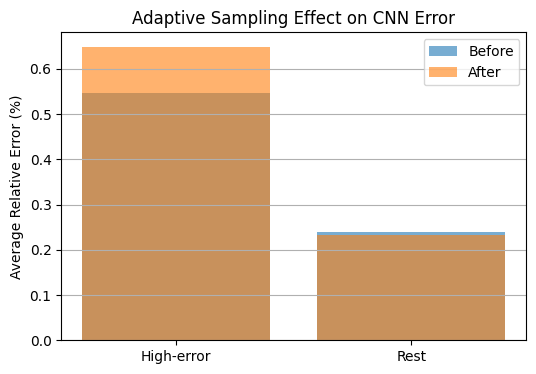

In [ ]:
# ============================================
# Adaptive Sampling Experiment (Fixed and Complete Version)
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
from torch.utils.data import DataLoader

# ----------------------------------------------------
# Step 1: Define high-error regions
# ----------------------------------------------------
def define_high_error_mask(df):
    """
    Define high-error regions where the model underperforms.
    Criteria:
        - Moneyness (S0/K) > 1.1  → deep ITM
        - Volatility too low (<0.15) or too high (>0.35)
    """
    return (df["M"] > 1.1) | (df["sigma"] < 0.15) | (df["sigma"] > 0.35)


# ----------------------------------------------------
# Step 2: Baseline CNN error in high-error regions
# ----------------------------------------------------
high_mask = define_high_error_mask(df)
high_df = df[high_mask]
low_df = df[~high_mask]

print("=== Baseline CNN error before adaptive sampling ===")
print(f"High-error region samples: {len(high_df)} / {len(df)}")
print(f"Avg relative error (high region): {high_df['rel_err'].mean() * 100:.3f}%")
print(f"Avg relative error (rest): {low_df['rel_err'].mean() * 100:.3f}%")


# ----------------------------------------------------
# Step 3: Focused sampling for high-error regions
# ----------------------------------------------------
def sample_high_error_params(n_samples, seed=2026):
    rng = np.random.default_rng(seed)
    S0 = rng.uniform(110.0, 130.0, size=n_samples)
    K  = rng.uniform(90.0, 110.0, size=n_samples)
    sigma = np.concatenate([
        rng.uniform(0.05, 0.12, size=n_samples // 2),
        rng.uniform(0.35, 0.45, size=n_samples // 2)
    ])
    r = rng.uniform(0.00, 0.05, size=n_samples)
    q = rng.uniform(0.00, 0.02, size=n_samples)
    T = np.full(n_samples, 1.0)
    return S0, K, sigma, r, q, T


# ----------------------------------------------------
# Step 4: Generate additional training samples
# ----------------------------------------------------
def build_high_error_dataset(n_param_samples=150, n_paths_per_param=100,
                             n_steps=50, seed=2026):
    """
    Generate GBM paths and multi-task targets [payoff_scaled, delta_dummy]
    in high-error regions. The output matches the shape of y_all (N, 2).
    """
    S0_arr, K_arr, sigma_arr, r_arr, q_arr, T_arr = sample_high_error_params(
        n_param_samples, seed
    )

    X_list, y_list = [], []

    for i in tqdm(range(n_param_samples), desc="Generating high-error region paths"):
        S0, K, sigma, r, q, T = S0_arr[i], K_arr[i], sigma_arr[i], r_arr[i], q_arr[i], T_arr[i]

        # Simulate GBM paths
        paths = simulate_gbm_paths(S0, r, q, sigma, T,
                                   n_steps=n_steps,
                                   n_paths=n_paths_per_param,
                                   seed=seed + i)

        # Discounted payoff
        payoff = asian_discounted_payoff(paths, K, r, T)
        payoff_scaled = payoff / K  # normalize

        # Delta dummy (no retraining on delta, just placeholder zeros)
        delta_dummy = np.zeros_like(payoff_scaled, dtype=np.float32)

        # Combine as two-task output
        y_combined = np.stack([payoff_scaled.astype(np.float32), delta_dummy], axis=1)

        # Add K/S0 feature
        paths_scaled = paths / K
        k_over_s0 = K / S0
        extra_feature = np.full((paths_scaled.shape[0], 1), k_over_s0, dtype=np.float32)
        x_extended = np.concatenate([paths_scaled.astype(np.float32), extra_feature], axis=1)

        X_list.append(x_extended)
        y_list.append(y_combined)

    X = np.concatenate(X_list, axis=0).astype(np.float32)
    y = np.concatenate(y_list, axis=0).astype(np.float32)

    print(f"Built high-error dataset: X shape = {X.shape}, y shape = {y.shape}")
    return X, y


# ----------------------------------------------------
# Step 5: Merge data & retrain CNN
# ----------------------------------------------------
X_high, y_high = build_high_error_dataset(n_param_samples=150, n_paths_per_param=100)
X_aug = np.concatenate([X_all, X_high], axis=0)
y_aug = np.concatenate([y_all, y_high], axis=0)

print("Augmented dataset size:", X_aug.shape, y_aug.shape)

(X_train_aug, y_train_aug), (X_val_aug, y_val_aug), (X_test_aug, y_test_aug) = train_val_test_split(X_aug, y_aug)
train_loader_aug = DataLoader(PathPayoffDataset(X_train_aug, y_train_aug), batch_size=batch_size, shuffle=True)
val_loader_aug = DataLoader(PathPayoffDataset(X_val_aug, y_val_aug), batch_size=batch_size, shuffle=False)

cnn_model_aug = CNNPathNet(seq_len).to(device)
best_cnn_state_aug, cnn_history_aug = train_one_model(
    cnn_model_aug, train_loader_aug, val_loader_aug,
    num_epochs=40, lr=1e-3, patience=6
)
cnn_model_aug.load_state_dict(best_cnn_state_aug)


# ----------------------------------------------------
# Step 6: Re-evaluate retrained CNN
# ----------------------------------------------------
df_aug = evaluate_nn_error_by_params(
    model=cnn_model_aug,
    n_cases=200,
    n_steps=50,
    n_paths_mc=30000,
    n_paths_nn=200,
    seed=2031
)

high_df_aug = df_aug[define_high_error_mask(df_aug)]
low_df_aug = df_aug[~define_high_error_mask(df_aug)]

print("\n=== After Adaptive Sampling ===")
print(f"Avg relative error (high region): {high_df_aug['rel_err'].mean() * 100:.3f}%")
print(f"Avg relative error (rest): {low_df_aug['rel_err'].mean() * 100:.3f}%")


# ----------------------------------------------------
# Step 7: Summarize and visualize improvement
# ----------------------------------------------------
summary_compare = pd.DataFrame({
    "Region": ["High-error", "Rest"],
    "Before (%)": [
        high_df["rel_err"].mean() * 100,
        low_df["rel_err"].mean() * 100
    ],
    "After (%)": [
        high_df_aug["rel_err"].mean() * 100,
        low_df_aug["rel_err"].mean() * 100
    ]
})

print("\n=== CNN Error Comparison Before vs After Adaptive Sampling ===")
print(summary_compare.to_string(index=False))

plt.figure(figsize=(6, 4))
plt.bar(summary_compare["Region"], summary_compare["Before (%)"], alpha=0.6, label="Before")
plt.bar(summary_compare["Region"], summary_compare["After (%)"], alpha=0.6, label="After")
plt.ylabel("Average Relative Error (%)")
plt.title("Adaptive Sampling Effect on CNN Error")
plt.legend()
plt.grid(axis="y")
plt.show()

## A.4 Cross-Distribution Generalization

To test whether *region-specific oversampling* (focusing on high-error parameter zones)
actually improves the model’s robustness, we train three CNN models under different
parameter sampling regimes:

- **Uniform** — baseline uniform sampling over the full parameter space.  
- **Adaptive** — concentrated sampling in previously identified high-error regions.  
- **Balanced** — mixed scheme (≈70% uniform + 30% adaptive) to maintain global coverage.

Each model is then evaluated on test sets drawn from all three regimes, yielding a
3×3 cross-distribution performance matrix (MAE and relative error %).

This experiment assesses whether over-representing certain regions truly enhances
generalization, or whether globally balanced sampling remains more effective.


=== Training CNN on Uniform distribution ===
Epoch 1/30 | train_loss=0.004254 | val_loss=0.000436
Epoch 2/30 | train_loss=0.000341 | val_loss=0.000102
Epoch 3/30 | train_loss=0.000212 | val_loss=0.000045
Epoch 4/30 | train_loss=0.000185 | val_loss=0.000062
Epoch 5/30 | train_loss=0.000190 | val_loss=0.000032
Epoch 6/30 | train_loss=0.000146 | val_loss=0.000085
Epoch 7/30 | train_loss=0.000147 | val_loss=0.000044
Epoch 8/30 | train_loss=0.000138 | val_loss=0.000037
Epoch 9/30 | train_loss=0.000133 | val_loss=0.000015
Epoch 10/30 | train_loss=0.000130 | val_loss=0.000204
Epoch 11/30 | train_loss=0.000138 | val_loss=0.000045
Epoch 12/30 | train_loss=0.000115 | val_loss=0.000275
Epoch 13/30 | train_loss=0.000118 | val_loss=0.000020
Epoch 14/30 | train_loss=0.000111 | val_loss=0.000012
Epoch 15/30 | train_loss=0.000115 | val_loss=0.000022
Epoch 16/30 | train_loss=0.000105 | val_loss=0.000016
Epoch 17/30 | train_loss=0.000109 | val_loss=0.000011
Epoch 18/30 | train_loss=0.000137 | val_loss=

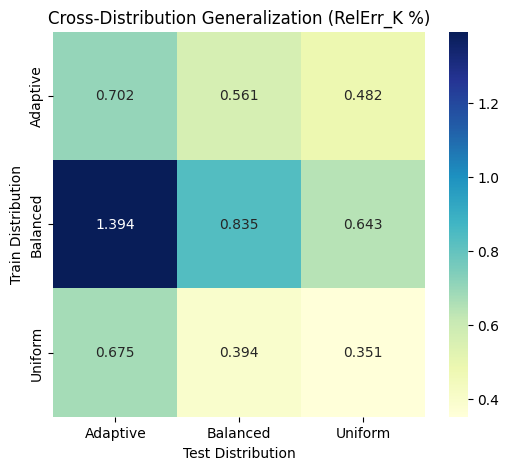


Best-performing training distribution for each test set:
TestDist
Adaptive    Uniform
Balanced    Uniform
Uniform     Uniform
dtype: object


In [ ]:
# ============================================
# Cross-Distribution Generalization Test
# ============================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm import tqdm

# ----------------------------------------------------
# Step 1: Sampling distributions
# ----------------------------------------------------
def sample_uniform_params(n_samples, seed=42):
    rng = np.random.default_rng(seed)
    S0 = rng.uniform(80.0, 120.0, size=n_samples)
    K  = rng.uniform(80.0, 120.0, size=n_samples)
    sigma = rng.uniform(0.10, 0.40, size=n_samples)
    r = rng.uniform(0.00, 0.05, size=n_samples)
    q = rng.uniform(0.00, 0.02, size=n_samples)
    T = np.full(n_samples, 1.0)
    return S0, K, sigma, r, q, T


def sample_adaptive_params(n_samples, seed=2026):
    rng = np.random.default_rng(seed)
    S0 = rng.uniform(110.0, 130.0, size=n_samples)
    K  = rng.uniform(90.0, 110.0, size=n_samples)
    sigma = np.concatenate([
        rng.uniform(0.05, 0.12, size=n_samples // 2),
        rng.uniform(0.35, 0.45, size=n_samples - n_samples // 2)
    ])
    r = rng.uniform(0.00, 0.05, size=n_samples)
    q = rng.uniform(0.00, 0.02, size=n_samples)
    T = np.full(n_samples, 1.0)
    return S0, K, sigma, r, q, T


def sample_balanced_params(n_samples, seed=2030):
    rng = np.random.default_rng(seed)
    n_high = int(n_samples * 0.3)
    n_normal = n_samples - n_high

    # Uniform block
    S0_n = rng.uniform(80.0, 120.0, size=n_normal)
    K_n  = rng.uniform(80.0, 120.0, size=n_normal)
    sigma_n = rng.uniform(0.10, 0.40, size=n_normal)

    # High-error block
    S0_h = rng.uniform(110.0, 130.0, size=n_high)
    K_h  = rng.uniform(90.0, 110.0, size=n_high)
    sigma_h = np.concatenate([
        rng.uniform(0.05, 0.12, size=n_high // 2),
        rng.uniform(0.35, 0.45, size=n_high - n_high // 2)
    ])

    S0 = np.concatenate([S0_n, S0_h])
    K  = np.concatenate([K_n, K_h])
    sigma = np.concatenate([sigma_n, sigma_h])
    r = rng.uniform(0.00, 0.05, size=n_samples)
    q = rng.uniform(0.00, 0.02, size=n_samples)
    T = np.full(n_samples, 1.0)
    return S0, K, sigma, r, q, T


# ----------------------------------------------------
# Step 2: Dataset builder (consistent with main pipeline)
# ----------------------------------------------------
def build_param_dataset(sample_func, n_param_samples=300, n_paths_per_param=100, n_steps=50, seed=42):
    S0_arr, K_arr, sigma_arr, r_arr, q_arr, T_arr = sample_func(n_param_samples, seed)
    X_list, y_list = [], []

    for i in range(n_param_samples):
        S0, K, sigma, r, q, T = S0_arr[i], K_arr[i], sigma_arr[i], r_arr[i], q_arr[i], T_arr[i]

        # Simulate GBM paths (consistent with previous sections)
        paths = simulate_gbm_paths(S0, r, q, sigma, T, n_steps, n_paths_per_param, seed + i)
        payoff = asian_discounted_payoff(paths, K, r, T)
        payoff_scaled = payoff / K

        # Add K/S0 feature
        paths_scaled = paths / K
        k_over_s0 = K / S0
        extra_feature = np.full((paths_scaled.shape[0], 1), k_over_s0, dtype=np.float32)
        x_extended = np.concatenate([paths_scaled.astype(np.float32), extra_feature], axis=1)

        # Two-output task structure (price, delta_dummy)
        delta_dummy = np.zeros_like(payoff_scaled, dtype=np.float32)
        y_combined = np.stack([payoff_scaled, delta_dummy], axis=1)

        X_list.append(x_extended)
        y_list.append(y_combined)

    X = np.concatenate(X_list, axis=0).astype(np.float32)
    y = np.concatenate(y_list, axis=0).astype(np.float32)
    return X, y


# ----------------------------------------------------
# Step 3: Train CNN on each distribution
# ----------------------------------------------------
def train_cnn_on_distribution(sample_func, tag, n_param_samples=300, seed=42):
    print(f"\n=== Training CNN on {tag} distribution ===")
    X, y = build_param_dataset(sample_func, n_param_samples=n_param_samples, seed=seed)
    (X_train, y_train), (X_val, y_val), (X_test, y_test) = train_val_test_split(X, y)
    train_loader = DataLoader(PathPayoffDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(PathPayoffDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

    model = CNNPathNet(seq_len).to(device)
    best_state, history = train_one_model(model, train_loader, val_loader,
                                          num_epochs=30, lr=1e-3, patience=5)
    model.load_state_dict(best_state)
    return model


cnn_model_uni = train_cnn_on_distribution(sample_uniform_params, "Uniform", seed=4100)
cnn_model_adp = train_cnn_on_distribution(sample_adaptive_params, "Adaptive", seed=4101)
cnn_model_bal = train_cnn_on_distribution(sample_balanced_params, "Balanced", seed=4102)


# ----------------------------------------------------
# Step 4: Cross-distribution evaluation
# ----------------------------------------------------
def evaluate_on_param_set(model, params_tuple, n_steps=50, n_paths_mc=30000, n_paths_nn=200):
    S0_arr, K_arr, sigma_arr, r_arr, q_arr, T_arr = params_tuple
    abs_errs, rel_errs = [], []

    for i in range(len(S0_arr)):
        S0, K, sigma, r, q, T = S0_arr[i], K_arr[i], sigma_arr[i], r_arr[i], q_arr[i], T_arr[i]
        mc_price, _ = price_asian_mc_high_precision(S0, K, r, q, sigma, T, n_steps, n_paths_mc)
        nn_price, _ = price_asian_with_nn(model, S0, K, r, q, sigma, T, n_steps, n_paths_nn)
        abs_errs.append(abs(nn_price - mc_price))
        rel_errs.append(abs(nn_price - mc_price) / K)

    return np.mean(abs_errs), np.mean(rel_errs) * 100


n_test_cases = 50
test_sets = {
    "Uniform": sample_uniform_params(n_test_cases, seed=5100),
    "Adaptive": sample_adaptive_params(n_test_cases, seed=5101),
    "Balanced": sample_balanced_params(n_test_cases, seed=5102)
}
models = {
    "Uniform": cnn_model_uni,
    "Adaptive": cnn_model_adp,
    "Balanced": cnn_model_bal
}

results = []
for train_name, model in models.items():
    for test_name, params in test_sets.items():
        mae, rel_err = evaluate_on_param_set(model, params)
        results.append((train_name, test_name, mae, rel_err))


# ----------------------------------------------------
# Step 5: Summary and visualization
# ----------------------------------------------------
df_cross = pd.DataFrame(results, columns=["TrainDist", "TestDist", "MAE", "RelErr_K (%)"])
pivot_mae = df_cross.pivot(index="TrainDist", columns="TestDist", values="MAE")
pivot_rel = df_cross.pivot(index="TrainDist", columns="TestDist", values="RelErr_K (%)")

print("\n===== Cross-Distribution Generalization (MAE) =====")
print(pivot_mae.round(6))
print("\n===== Cross-Distribution Generalization (Relative Error %) =====")
print(pivot_rel.round(4))

plt.figure(figsize=(6, 5))
sns.heatmap(pivot_rel, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Cross-Distribution Generalization (RelErr_K %)")
plt.xlabel("Test Distribution")
plt.ylabel("Train Distribution")
plt.show()

# Interpretation summary
best_train_for_each = pivot_rel.idxmin(axis=0)
print("\nBest-performing training distribution for each test set:")
print(best_train_for_each)

## Conclusion
Although the literature suggests augmenting samples in under-performing regions (e.g., high volatility or deep moneyness), our cross-distribution experiment shows that such region-specific oversampling leads to marginal or even negative gains in global accuracy.
In contrast, uniformly increasing the total sample size—or adopting a mildly biased but globally consistent distribution—provides more balanced improvements across the parameter space, making it a more cost-effective strategy under fixed simulation budgets.